## Импорт библиотек

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import io
import time
import json
import shutil
import zipfile
import requests
import textwrap

import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator
from rich.progress import track
from pathlib import Path

from scipy.signal import find_peaks
from scipy.stats import kurtosis, skew, pearsonr
from scipy.signal.windows import blackman

from sklearn.feature_selection import RFECV
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, StackingClassifier, VotingClassifier


## Создание названий признаков

In [2]:
# Список для хранения названий всех признаков
cols = []

# Базовые статистические признаки
common_cols = ["Median", "Mean", "Std", "Ptp", "Max", "Min", "P90", "P75", "P25", 
               "L1", "Kurtosis", "Skewness", "Integral", "RMS", "IntegralSq", 
               "SumSq", "CumsumFinal", "CumsumMax", "CumsumMin", "CumsumRange", 
               "Variation", "OutlierCount", "PeakCount"]

# Спектральные признаки
frequency_cols = ["EnergySpectralCentroid", "EnergySpectralBandwidth", 
                  "MeanAmpAbove10Hz", "StdAmpAbove10Hz", "EnergyAbove10Hz"]

# Признаки для магнитуд гироскопа и акселерометра
for channel in ["mag_g", "mag_a"]:
    for dif in ["", "dif_", "dif_dif_"]:
        for col_name in common_cols:
            cols.append(f"{channel}_TD_{dif}{col_name}")

# Признаки для каждой оси отдельно
for channel in ["gx", "gy", "gz", "ax", "ay", "az"]:
    for dif in ["", "dif_", "dif_dif_"]:
        for col_name in common_cols:
            cols.append(f"{channel}_TD_{dif}{col_name}")
        for col_name in common_cols + frequency_cols:
            cols.append(f"{channel}_FD_{dif}{col_name}")

# Подсчет общего количества признаков
num_of_features = len(cols)

# Добавление целевой переменной и создание пустого DataFrame
cols.append("Класс")
features_df_orig = pd.DataFrame(columns=cols)

print(f"Количество признаков: {num_of_features}")


Количество признаков: 1056


## Функция для извлечения признаков

In [3]:
def feature_extraction(seg, features, frequencies=None, more10hz_idx=None):
    
    # Предварительные вычисления
    square_seg = seg**2
    sum_square_seg = np.sum(square_seg)
    
    std_seg = np.std(seg)
    mean_seg = np.mean(seg)
    median_seg = np.median(seg)

    cumsum = np.cumsum(seg)
    max_cumsum = np.max(cumsum)
    min_cumsum = np.min(cumsum)

    # Базовые статистики
    features.append(median_seg)              # Медиана
    features.append(mean_seg)                # Средняя амплитуда
    features.append(std_seg)                 # Стандартное отклонение
    features.append(np.ptp(seg))             # Размах
    features.append(np.max(seg))             # Максимальная амплитуда
    features.append(np.min(seg))             # Минимальная амплитуда
    features.append(np.percentile(seg, 90))  # 90-й процентиль
    features.append(np.percentile(seg, 75))  # 75-й процентиль
    features.append(np.percentile(seg, 25))  # 25-й процентиль
    features.append(np.sum(np.abs(seg)))     # Сумма модулей
    
    # Форма распределения
    features.append(kurtosis(seg))  # Куртозис
    features.append(skew(seg))      # Ассиметрия

    # Энергетические характеристики
    features.append(np.trapz(seg))                 # Интеграл
    features.append(np.sqrt(np.mean(square_seg)))  # RMS    
    features.append(np.trapz(square_seg))          # Интеграл (квадрат)
    features.append(sum_square_seg)                # Сумма квадратов

    # Кумулятивные характеристики
    features.append(cumsum[-1])               # Чистый дрейф за окно
    features.append(max_cumsum)               # Максимум накопления
    features.append(min_cumsum)               # Минимум накопления  
    features.append(max_cumsum - min_cumsum)  # Размах дрейфа
    
    # Коэффициент вариации
    features.append(std_seg / mean_seg if mean_seg != 0 else 0)  
    
    # Количество выбросов
    features.append(np.sum(np.abs(seg - median_seg) > 0.5 * std_seg))

    # Количество пиков
    features.append(len(find_peaks(seg, height=median_seg + 0.5 * std_seg)[0]))

    # Спектральные моменты
    if frequencies is not None:
        # Центр тяжести спектра
        centroid = np.sum(frequencies * square_seg) / sum_square_seg
        features.append(centroid) 
        # Ширина
        features.append(np.sqrt(np.sum((frequencies - centroid)**2 * square_seg) / sum_square_seg))  

    # Исследование частот >10 Гц
    if more10hz_idx is not None:
        amp_half_10 = seg[more10hz_idx:]
        features.append(np.mean(amp_half_10))        # Средняя амплитуда частот >10 Гц
        features.append(np.std(amp_half_10))         # Стандартное отклонение частот >10 Гц
        features.append(np.trapz(amp_half_10 ** 2))  # Энергия частот >10 Гц (квадрат)
        
    return features


## Извлечение признаков

In [4]:
Fs = 200                           # Частота дискретизации данных (Гц)
overlaps = [50, 75]                # Перекрытия окон (%)
window_sizes = [256, 128, 64, 32]  # Размеры окон

data_dir = 'DATA/flights'  # Путь к папкам с данными
class_folders = {
    1.0: '1.0', 
    0.9: '0.9', 
    0.8: '0.8', 
    0.7: '0.7', 
    0.6: '0.6',  
    0.5: '0.5', 
}

for window_size in window_sizes:
    window = blackman(window_size)                  # Окно Блэкмана-Наталла для уменьшения утечки спектра
    freqs_0 = np.fft.rfftfreq(window_size, 1 / Fs)  # Получение только положительных частот для спектра
    more10hz_idx_0 = np.sum(freqs_0 < 10)           # Индекс для частот более 10 Гц

    freqs_1 = (freqs_0[:-1] + freqs_0[1:]) / 2      # для diff_amp_half
    more10hz_idx_1 = np.sum(freqs_1 < 10)           # Индекс для частот более 10 Гц
    
    freqs_2 = (freqs_1[:-1] + freqs_1[1:]) / 2      # для diff_diff_amp_half
    more10hz_idx_2 = np.sum(freqs_2 < 10)           # Индекс для частот более 10 Гц
    
    for stride in [window_size * (1 - overlaps[0] / 100), window_size * (1 - overlaps[1] / 100)]:  # Цикл по перекрытиям 50% и 75%
        features_df = features_df_orig.copy(deep=True)
        
        for _, (class_label, folder_name) in zip(trange(len(class_folders), desc='Progress', colour='blue'), class_folders.items()):
            folder_path = os.path.join(data_dir, folder_name)   
            file_names = [name for name in os.listdir(folder_path) if name.endswith('.csv')]
            
            for _, file_name in zip(trange(len(file_names), desc='Progress', colour='green'), file_names):
                file_path = os.path.join(folder_path, file_name)
        
                # Загрузка данных из CSV-файла и извлечение значений гироскопа и акселерометра
                df = pd.read_csv(file_path)
                data = df[['gx', 'gy', 'gz', 'ax', 'ay', 'az']].values  
        
                # Скользящее окно по даннымс заданным шагом
                for start in range(0, len(data) - window_size + 1, stride):
                    segment = data[start:start + window_size]
                    segment_windowed = segment * window[:, None]  # Наложение окна
                    
                    yf = np.fft.rfft(segment_windowed, axis=0)    # Применение БПФ
                    amplitude = np.abs(yf)                        # Извлечение амплитуд

                    features = []
        
                    # Извлечение признаков из магнитуд гироскопа и акселерометра, их производных и производных их производных
                    mag_g = np.sqrt(segment[:, 0]**2 + segment[:, 1]**2 + segment[:, 2]**2)
                    mag_a = np.sqrt(segment[:, 3]**2 + segment[:, 4]**2 + segment[:, 5]**2)
        
                    # Первые производные магнитуд
                    diff_mag_g = np.diff(mag_g)
                    diff_diff_mag_g = np.diff(diff_mag_g)
        
                    # Вторые производные магнитуд
                    diff_mag_a = np.diff(mag_a)
                    diff_diff_mag_a = np.diff(diff_mag_a)
                            
                    # Извлечение временных признаков из всех данных магнитуд
                    for seg in [mag_g, diff_mag_g, diff_diff_mag_g, mag_a, diff_mag_a, diff_diff_mag_a]:
                        features = feature_extraction(seg, features)

                    # Извлечение признаков из каждой оси гироскопа и акселерометра, их производных и производных их производных
                    for channel in range(amplitude.shape[1]):
                        amp_half = amplitude[:, channel] 
                        
                        diff_amp_half = np.diff(amp_half)            # Первая производная амплитуд спектра
                        diff_diff_amp_half = np.diff(diff_amp_half)  # Вторая производная амплитуд спектра
                        
                        seg = segment[:, channel]                     
                        diff_seg = np.diff(seg)                      # Первая производная временных данных
                        diff_diff_seg = np.diff(diff_seg)            # Вторая производная временных данных
        
                        # Обработка исходных данных и их производных
                        for i, (amp_half_i, seg_i, freqs, more10hz_idx) in enumerate([[amp_half, seg, freqs_0, more10hz_idx_0], 
                                                                                      [diff_amp_half, diff_seg, freqs_1, more10hz_idx_1], 
                                                                                      [diff_diff_amp_half, diff_diff_seg, freqs_2, more10hz_idx_2]]):
                            
                            features = feature_extraction(seg_i, features)                            # Извлечение временных признаков
                            features = feature_extraction(amp_half_i, features, freqs, more10hz_idx)  # Извлечение частотных признаков
                    
                    # Добавляем метку класса и сохраняем извлеченные признаки
                    features.append(class_label)
                    features_df.loc[len(features_df)] = features
        
        features_df = features_df.fillna(0)
        features_df.to_csv(f"MATLAB/DATA/features/MATLAB_features_ws{window_size}_stride{int((1 - stride / window_size) * 100)}.csv", index=False)             
        print(f"Строк данных сохранено: {len(features_df)}")

## Обучение моделей

In [4]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)


def prepare_data(features_df, test_features_df, test_size=0.2, scaler_type=None, random_state=42):
    """
    Подготавливает данные для обучения: разделяет на признаки и целевую переменную,
    преобразует классы в целые числа, разделяет на train/test и масштабирует при необходимости.
    
    Parameters:
    -----------
    features_df : DataFrame
        Исходные данные с колонкой "Класс"
    test_size : float
        Доля тестовой выборки
    random_state : int
        Для воспроизводимости
    scaler_type : str or None
        Тип масштабирования: 'standard', 'minmax', 'robust', 'power' или None
    
    Returns:
    --------
    X_train, X_test, y_train, y_test : массивы подготовленных данных
    """
    
    # Разбиение данных на признаки и целевую переменную
    X = features_df.drop(columns=["Класс"])
    y = features_df["Класс"].values

    separate_X_test = test_features_df.drop(columns=["Класс"])
    separate_y_test = test_features_df["Класс"].values

    # Преобразование y: (1.0 -> 0, 0.9 -> 1, 0.8 -> 2, 0.7 -> 3, 0.6 -> 4, 0.5 -> 5)
    class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))}
    y = np.array([class_mapping[val] for val in y])
    separate_y_test = np.array([class_mapping[val] for val in separate_y_test])

    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    # Для SVM, KNN, Logistic Regression 
    if scaler_type == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        separate_X_test = scaler.transform(separate_X_test)

    # Для нейросетей
    elif scaler_type == "minmax":
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        separate_X_test = scaler.transform(separate_X_test)

    # Если есть выбросы
    elif scaler_type == "robust":
        scaler = RobustScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        separate_X_test = scaler.transform(separate_X_test)

    # Если данные не нормально распределены (скошенные)
    elif scaler_type == "power":
        power = PowerTransformer(method="yeo-johnson")
        X_train = power.fit_transform(X_train)
        X_test = power.transform(X_test)
        separate_X_test = power.transform(separate_X_test)

    return X_train, X_test, separate_X_test, y_train, y_test, separate_y_test


def train_and_evaluate(models, all_results, results_key, X_train_raw, X_test_raw, separate_X_test_raw, X_train_std, X_test_std, separate_X_test_std, y_train, y_test, separate_y_test):
    """
    Обучает переданные модели, оценивает их качество и сохраняет результаты.
    
    Parameters:
    -----------
    models : dict
        Словарь моделей {имя_модели: объект_модели}
    all_results : dict
        Словарь для накопления результатов
    results_key : str
        Ключ для текущего набора данных
    X_train_raw, X_test_raw : array
        Данные без масштабирования
    X_train_std, X_test_std : array
        Данные со StandardScaler
    y_train, y_test : array
        Целевые переменные
    
    Returns:
    --------
    trained_models : dict
        Словарь сохраненных моделей
    all_results : dict
        Обновленный словарь результатов
    """
    
    trained_models = {}
    ensamble_models = ["CatBoost", "XGBoost", "LightGBM"]
    
    for model_name, model in models.items():
        
        # Выбор подходящих данных для конкретной модели
        if model_name in ["K-Nearest Neighbors", "Logistic Regression"]:
            X_train, X_test, separate_X_test = X_train_std, X_test_std, separate_X_test_std
        else:
            X_train, X_test, separate_X_test = X_train_raw, X_test_raw, separate_X_test_raw

        print("-" * 53)
        print(f"\n{model_name}")
        
        # Обучение
        start_train = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_train
        
        # Сохраняем обученную модель, если она используется в Stacking и Voting
        if model_name in ensamble_models:
            trained_models[model_name] = model
        
        # Инференс
        start_predict = time.time()
        y_pred = model.predict(X_test)
        separate_y_pred = model.predict(separate_X_test)
        predict_time = time.time() - start_predict

        # Расчет метрик качества
        accuracy = accuracy_score(y_test, y_pred) * 100
        precision = precision_score(y_test, y_pred, average="weighted") * 100
        recall = recall_score(y_test, y_pred, average="weighted") * 100
        f1 = f1_score(y_test, y_pred, average="weighted") * 100

        accuracy_sep = accuracy_score(separate_y_test, separate_y_pred) * 100
        precision_sep = precision_score(separate_y_test, separate_y_pred, average="weighted") * 100
        recall_sep = recall_score(separate_y_test, separate_y_pred, average="weighted") * 100
        f1_sep = f1_score(separate_y_test, separate_y_pred, average="weighted") * 100

        # Время на одно предсказание (в миллисекундах)
        time_per_pred = predict_time / (len(y_test) + len(separate_y_test)) * 1000

        # Сохранение результатов
        all_results[results_key][model_name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_Score": round(f1, 3),
            "Accuracy_Sep": round(accuracy_sep, 3),
            "Precision_Sep": round(precision_sep, 3),
            "Recall_Sep": round(recall_sep, 3),
            "F1_Score_Sep": round(f1_sep, 3),
            "Training_Time": round(training_time, 2),
            "Inference_Time": round(predict_time, 4),
            "Time_per_pred_ms": round(time_per_pred, 4)
        }

        all_results[results_key][model_name]["Confusion_Matrix"] = confusion_matrix(y_test, y_pred).tolist()
        all_results[results_key][model_name]["Confusion_Matrix_Sep"] = confusion_matrix(separate_y_test, separate_y_pred).tolist()
        
        # Вывод результатов
        print(f"Время обучения: {training_time:.2f} с")
        print(f"Время инференса: {predict_time:.3f} с, {time_per_pred:.4f} мс на 1 предсказание\n")
        print(classification_report(y_test, y_pred))
        print(f"Accuracy:\t{accuracy:.2f} %")
        print(f"Accuracy Sep:\t{accuracy_sep:.2f} %")
        
    return trained_models, all_results


In [6]:
features_df = pd.read_csv(f"DATA/features/MATLAB_features_ws64_overlap75.csv")

In [14]:
features_df_2 = pd.read_csv(f"DATA/features_test_flight/MATLAB_TEST_features_ws64_overlap75.csv")

In [10]:
# Объединение по строкам (вертикальное)
combined_df = pd.concat([features_df, features_df_2], axis=0, ignore_index=True)

print(f"Размер первого датасета: {features_df.shape}")
print(f"Размер второго датасета: {features_df_2.shape}")
print(f"Размер объединенного датасета: {combined_df.shape}")

Размер первого датасета: (283108, 1057)
Размер второго датасета: (23438, 1057)
Размер объединенного датасета: (306546, 1057)


In [ ]:
X = combined_df.drop(columns=["Класс"])
y = combined_df["Класс"].values
print(y[0])
class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))}
y = np.array([class_mapping[val] for val in y])
print(y[0])

In [21]:
features_df = pd.read_csv(f"DATA/features/MATLAB_features_ws64_overlap75.csv")

X = features_df.drop(columns=["Класс"])
y = features_df["Класс"].values
print(y[0])
class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))}
y = np.array([class_mapping[val] for val in y])
print(y[0])

# X, _ , y, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = XGBClassifier(
    random_state=42, 
    device="cuda", 
    tree_method="hist", 
    n_jobs=-1,
    n_estimators=300,
    max_depth=10,
    learning_rate=0.25,
    colsample_bytree=1,
    subsample=1,
    gamma=0,
    min_child_weight=1
)

model.fit(X, y)

with open(f'MATLAB_xgb_model_64_75_ts0.pkl', 'wb') as f:
    pickle.dump(model, f)



0.5
5


In [20]:
with open(f'xgb_model_64_75_ts0.pkl', 'wb') as f:
    pickle.dump(model, f)

In [5]:
overlaps = [75]                # Перекрытия окон (%)
window_sizes = [64]  # Размеры окон
import pickle

file_names = [f"MATLAB_features_ws{w}_overlap{s}.csv" for w in window_sizes for s in overlaps]
test_file_names = [f"MATLAB_TEST_features_ws{w}_overlap{s}.csv" for w in window_sizes for s in overlaps]

all_results = {}
random_state = 42

for (file_name, test_file_name) in zip(file_names, test_file_names):
    print(f"\n\n{'=' * 53}")
    print(f"ОБРАБОТКА ФАЙЛА: {file_name}")
    print('=' * 53)

    # Загрузка данных
    features_df = pd.read_csv(f"DATA/features/{file_name}")
    test_features_df = pd.read_csv(f"DATA/features_test_flight/{test_file_name}")
    print("\nДанные загружены")

    # Подготовка данных без масштабирования
    X_train_raw, X_test_raw, separate_X_test_raw, y_train, y_test, separate_y_test = prepare_data(features_df, test_features_df, test_size=0.2, scaler_type=None, random_state=random_state)
    
    # Подготовка данных с использованием StandardScaler 
    X_train_std, X_test_std, separate_X_test_std, _, _, _ = prepare_data(features_df, test_features_df, test_size=0.2, scaler_type="standard", random_state=random_state)
    print("Предобработка и разбиение на train/test завершены\n")

    # Инициализация базовых моделей
    # models = {
        # "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=37, leaf_size=1, p=1, metric='manhattan', weights='uniform'),
        # "Logistic Regression": LogisticRegression(random_state=random_state),
        # "Naive Bayes": GaussianNB(var_smoothing=1e-5),
        # "Decision Tree": DecisionTreeClassifier(max_depth=30, criterion='entropy', random_state=random_state),
        # "CatBoost": CatBoostClassifier(silent=True, random_state=random_state, task_type="GPU", devices="0:1:2:3", allow_writing_files=False, save_snapshot=False),
        # "Histogram-based Gradient Boosting": HistGradientBoostingClassifier(random_state=random_state),
        # "XGBoost": XGBClassifier(random_state=random_state, device="cuda", tree_method="hist", n_jobs=-1),
        # "LightGBM": LGBMClassifier(verbose=-1, random_state=random_state)
    # }
    X = features_df.drop(columns=["Класс"])
    y = features_df["Класс"].values
    
    models = {
    # "CatBoost": CatBoostClassifier(
    #     random_state=random_state, 
    #     task_type="GPU", 
    #     devices="0:1:2:3", 
    #     silent=True, 
    #     allow_writing_files=False, 
    #     save_snapshot=False,
    #     iterations=300,
    #     depth=10,
    # ),
    # "Histogram-based Gradient Boosting": HistGradientBoostingClassifier(
    #     random_state=random_state,
    #     max_iter=300,
    #     max_depth=10,
    # ),
    "XGBoost": XGBClassifier(
        random_state=random_state, 
        device="cuda", 
        tree_method="hist", 
        n_jobs=-1,
        n_estimators=300,
        max_depth=10,
        learning_rate=0.25,
        colsample_bytree=1,
        subsample=1,
        gamma=0,
        min_child_weight=1
    )
    # "LightGBM": LGBMClassifier(
    #     random_state=random_state,
    #     verbose=-1,
    #     n_estimators=300,
    #     max_depth=10,
    # )
}

    # Инициализация хранилища результатов
    results_key = f"{file_name}"
    all_results[results_key] = {}

    # Обучение базовых моделей
    # trained_models, all_results = train_and_evaluate(models, all_results, results_key, X_train_raw, X_test_raw, separate_X_test_raw, X_train_std, X_test_std, separate_X_test_std, y_train, y_test, separate_y_test)
    models["XGBoost"].fit(X, y)
    # Сохраняем модель XGBoost
    if model_name == "XGBoost":
        with open(f'xgb_model_{window_size}_{overlap}.pkl', 'wb') as f:
            pickle.dump(trained_models[model_name], f)
        print(f"Модель XGBoost сохранена как xgb_model_{window_size}_{overlap}.pkl")
        
    # Создание ансамблей на основе сохраненных моделей
    # new_models = {
    #     "Stacking Classifier": StackingClassifier(
    #         estimators=[("LightGBM", trained_models["LightGBM"]),
    #                     ("XGBoost", trained_models["XGBoost"]),
    #                     ("CatBoost", trained_models["CatBoost"])],
    #         final_estimator=LogisticRegression(random_state=random_state)),
        
    #     "Voting Classifier": VotingClassifier(
    #         estimators=[("LightGBM", trained_models["LightGBM"]),
    #                     ("XGBoost",trained_models["XGBoost"]),
    #                     ("CatBoost", trained_models["CatBoost"])],
    #         voting='soft')
    # }

    # # Обучение ансамблей
    # _, all_results = train_and_evaluate(new_models, all_results, results_key, X_train_raw, X_test_raw, separate_X_test_raw, X_train_std, X_test_std, separate_X_test_std, y_train, y_test, separate_y_test)

# Сохранение результатов обучения в json файл
with open('DATA/related_info/models_training_results_GB.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=4, cls=NumpyEncoder, ensure_ascii=False)
print(f"\nРезультаты сохранены в json файл")




ОБРАБОТКА ФАЙЛА: MATLAB_features_ws256_overlap50.csv

Данные загружены
Предобработка и разбиение на train/test завершены

-----------------------------------------------------

CatBoost
Время обучения: 53.42 с
Время инференса: 0.153 с, 0.0153 мс на 1 предсказание

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1171
           1       0.71      0.72      0.72      1178
           2       0.73      0.72      0.72      1175
           3       0.75      0.72      0.73      1176
           4       0.72      0.78      0.75      1179
           5       0.90      0.87      0.88      1180

    accuracy                           0.77      7059
   macro avg       0.77      0.77      0.77      7059
weighted avg       0.77      0.77      0.77      7059

Accuracy:	77.14 %
Accuracy Sep:	77.60 %
-----------------------------------------------------

Histogram-based Gradient Boosting
Время обучения: 80.45 с
Время инференса: 0.186 с, 0.0186 мс н

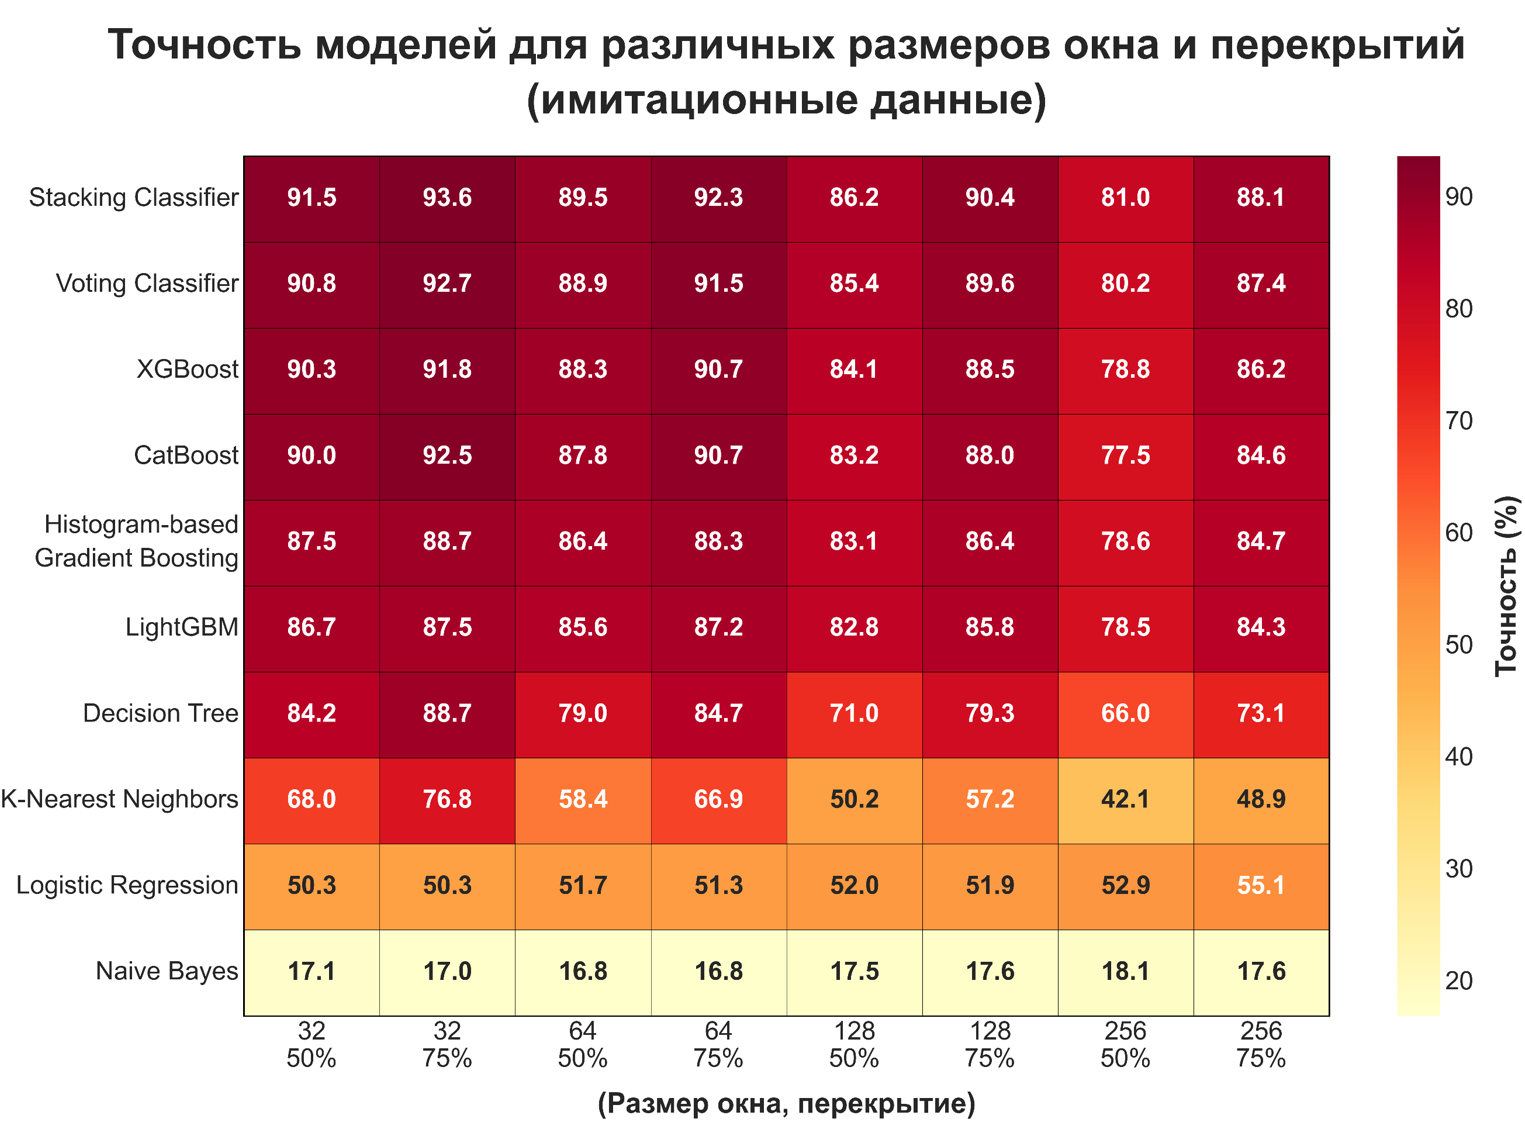

## Сравнение моделей

In [8]:
# Настройка стилей для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Загрузка результатов
with open('DATA/related_info/models_training_results.json', 'r', encoding='utf-8') as f:
    all_results = json.load(f)

print(f"Загружено результатов для {len(all_results)} конфигураций")


Загружено результатов для 8 конфигураций


In [ ]:
    # models = {
        # "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=37, leaf_size=1, p=1, metric='manhattan', weights='uniform'),
        # "Logistic Regression": LogisticRegression(random_state=random_state),
        # "Naive Bayes": GaussianNB(var_smoothing=1e-5),
        # "Decision Tree": DecisionTreeClassifier(max_depth=30, criterion='entropy', random_state=random_state),
        # "CatBoost": CatBoostClassifier(silent=True, random_state=random_state, task_type="GPU", devices="0:1:2:3", allow_writing_files=False, save_snapshot=False),
        # "Histogram-based Gradient Boosting": HistGradientBoostingClassifier(random_state=random_state),
        # "XGBoost": XGBClassifier(random_state=random_state, device="cuda", tree_method="hist", n_jobs=-1),
        # "LightGBM": LGBMClassifier(verbose=-1, random_state=random_state)
    # }

    # new_models = {
    #     "Stacking Classifier": StackingClassifier(
    #         estimators=[("LightGBM", trained_models["LightGBM"]),
    #                     ("XGBoost", trained_models["XGBoost"]),
    #                     ("CatBoost", trained_models["CatBoost"])],
    #         final_estimator=LogisticRegression(random_state=random_state)),
        
    #     "Voting Classifier": VotingClassifier(
    #         estimators=[("LightGBM", trained_models["LightGBM"]),
    #                     ("XGBoost",trained_models["XGBoost"]),
    #                     ("CatBoost", trained_models["CatBoost"])],
    #         voting='soft')
    # }

In [10]:
# Создаем DataFrame для всех результатов
# data = []
for file_name, models_results in all_results.items():
    # Извлекаем ws и overlap из имени файла
    ws = int(file_name.split('ws')[1].split('_')[0])
    overlap = int(file_name.split('overlap')[1].split('.')[0])
    
    for model_name, metrics in models_results.items():
        if model_name in ["CatBoost", "Histogram-based Gradient Boosting", "XGBoost", "LightGBM", "Stacking Classifier", "Voting Classifier"]:
            continue
        data.append({
            'Window Size': ws,
            'Overlap': overlap,
            'Model': model_name,
            'Accuracy': metrics['Accuracy'],
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall'],
            'F1_Score': metrics['F1_Score'],
            'Accuracy_Sep': metrics['Accuracy_Sep'],
            'Precision_Sep': metrics['Precision_Sep'],
            'Recall_Sep': metrics['Recall_Sep'],
            'F1_Score_Sep': metrics['F1_Score_Sep'],
            'Training_Time': metrics['Training_Time'],
            'Inference_Time': metrics['Inference_Time'],
            'Time_per_pred_ms': metrics['Time_per_pred_ms']
        })

df_results = pd.DataFrame(data)
df_results


,Window Size,Overlap,Model,Accuracy,Precision,Recall,F1_Score,Accuracy_Sep,Precision_Sep,Recall_Sep,F1_Score_Sep,Training_Time,Inference_Time,Time_per_pred_ms
0,256,50,CatBoost,77.136,77.272,77.136,77.171,77.599,77.831,77.599,77.643,53.42,0.1527,0.0153
1,256,50,Histogram-based Gradient Boosting,81.385,81.575,81.385,81.447,81.635,81.739,81.635,81.598,80.45,0.1861,0.0186
2,256,50,XGBoost,80.833,80.892,80.833,80.821,81.874,81.879,81.874,81.798,59.52,0.4102,0.0411
3,256,50,LightGBM,81.697,81.852,81.697,81.735,82.250,82.470,82.250,82.277,32.63,0.1194,0.0120
4,256,50,Stacking Classifier,83.496,83.716,83.496,83.566,85.499,85.688,85.499,85.530,804.05,0.5184,0.0519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,32,50,Decision Tree,84.200,84.222,84.200,84.208,72.128,72.352,72.128,72.190,705.74,0.0959,0.0012
76,32,75,K-Nearest Neighbors,76.779,77.170,76.779,76.882,47.759,50.488,47.759,48.522,1.12,3012.0133,18.8011
77,32,75,Logistic Regression,50.334,49.862,50.334,49.625,49.561,48.853,49.561,48.892,37.70,0.1191,0.0007
78,32,75,Naive Bayes,16.958,19.987,16.958,6.350,16.713,19.022,16.713,5.568,4.98,3.1351,0.0196


## График 1: Тепловая карта точности моделей для разных ws и overlap

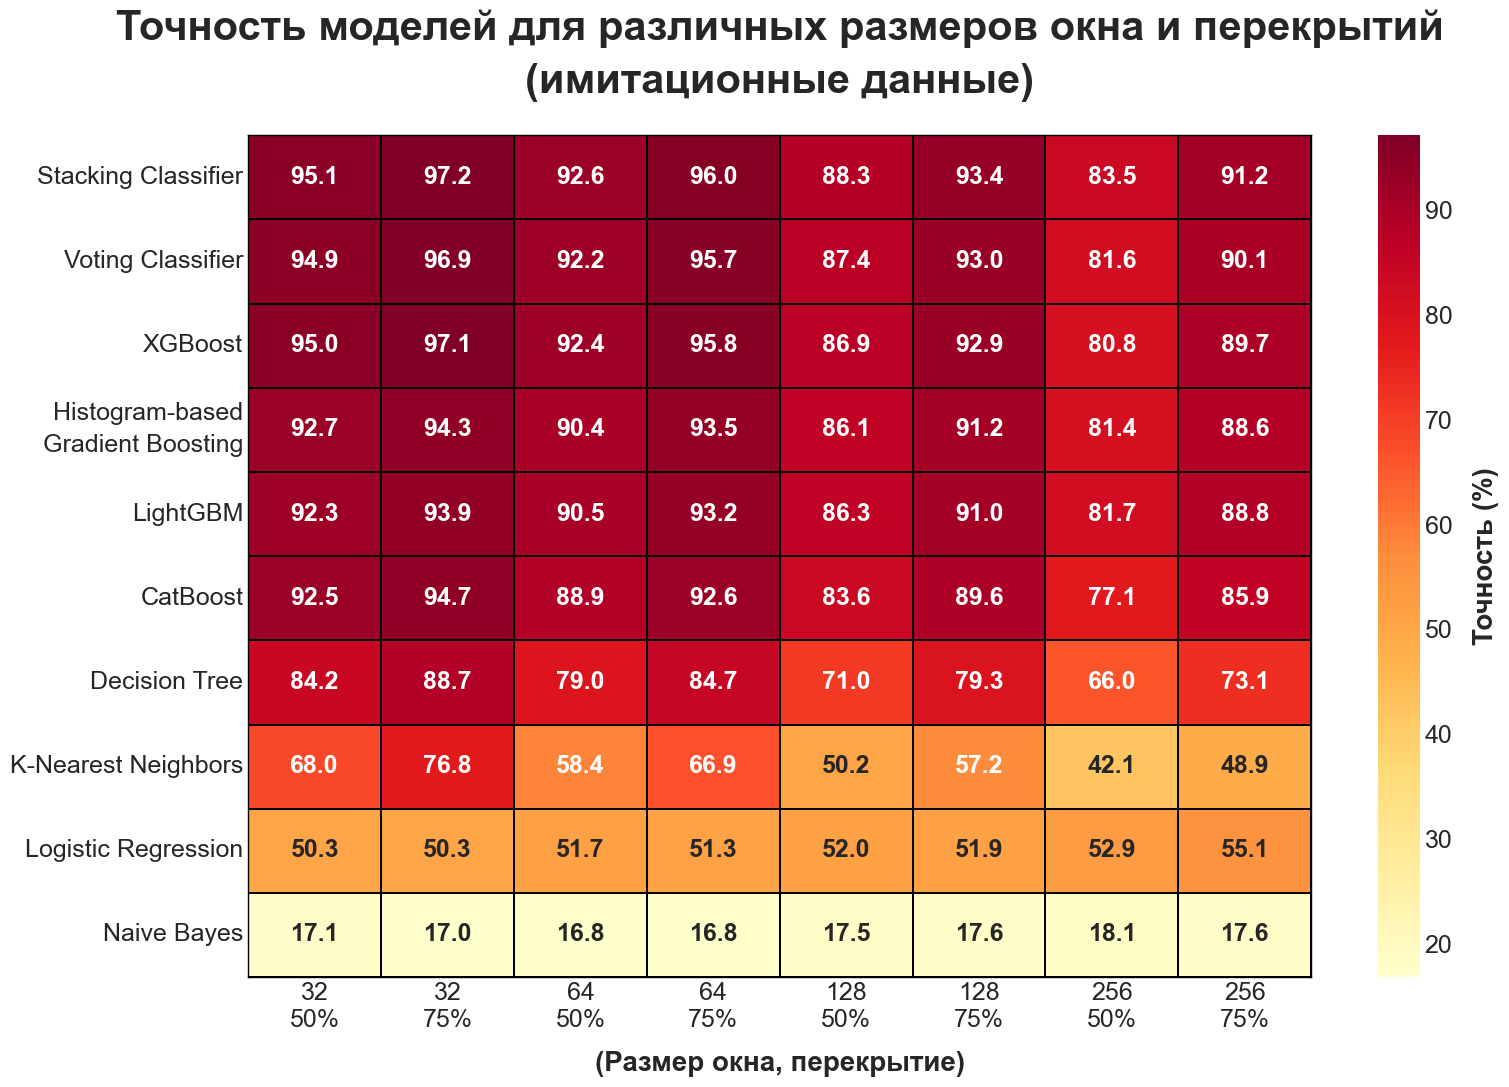

In [11]:
plt.figure(figsize=(16, 11))

# Создание сводной таблицы
pivot_accuracy = df_results.pivot_table(
    values='Accuracy', 
    index='Model', 
    columns=['Window Size', 'Overlap']
)

# Сортировка моделей по средней точности
model_order = df_results.groupby('Model')['Accuracy'].mean().sort_values(ascending=False).index
pivot_accuracy = pivot_accuracy.reindex(model_order)
pivot_accuracy = pivot_accuracy.rename(columns={'Histogram-based Gradient Boosting': 'Histogram-based\nGradient Boosting'})

# Создание тепловой карты
ax = sns.heatmap(pivot_accuracy, 
                 annot=True, 
                 fmt='.1f', 
                 cmap='YlOrRd', 
                 linecolor='black',
                 linewidths=0.3, 
                 cbar=True,
                 annot_kws={'size': 18, 'weight': 'bold'})


def wrap_labels(labels, width=25):
    wrapped = []
    for label in labels:
        # Убираем существующий \n и заменяем на пробел, затем переносим
        clean_label = label.replace('\n', ' ')
        if len(clean_label) > width:
            wrapped.append('\n'.join(textwrap.wrap(clean_label, width)))
        else:
            wrapped.append(label)  # сохраняем исходный \n если он есть
    return wrapped

# Применяем перенос к y-тикам
y_labels = wrap_labels(pivot_accuracy.index, width=20)
ax.set_yticklabels(y_labels, fontsize=16, fontweight='medium', rotation=0, linespacing=1.5)

# Настройка x-тиков (если нужно переносить длинные названия колонок)
x_labels = [f'{w}\n{o}%' for w, o in pivot_accuracy.columns]
ax.set_xticklabels(x_labels, fontsize=16, fontweight='medium', rotation=0)


# Чёрная рамка вокруг графика
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)
    
# Настройка цветовой шкалы
cbar = ax.collections[0].colorbar
cbar.set_label('Точность (%)', fontsize=20, fontweight='bold')
cbar.ax.tick_params(labelsize=18)
cbar.ax.yaxis.labelpad = 15

# Настройка параметров графика
plt.title('Точность моделей для различных размеров окна и перекрытий\n(имитационные данные)', fontsize=30, fontweight='bold', pad=30, linespacing=1.5)
plt.xlabel('(Размер окна, перекрытие)', fontsize=20, fontweight='bold', labelpad=14)
plt.ylabel('')
plt.xticks(rotation=0, fontsize=18, fontweight='medium')
plt.yticks(rotation=0, fontsize=18, fontweight='medium')
plt.tight_layout()
plt.savefig('APPLICATIONS/accuracy_heatmap.png', dpi=600, bbox_inches='tight')
plt.show()


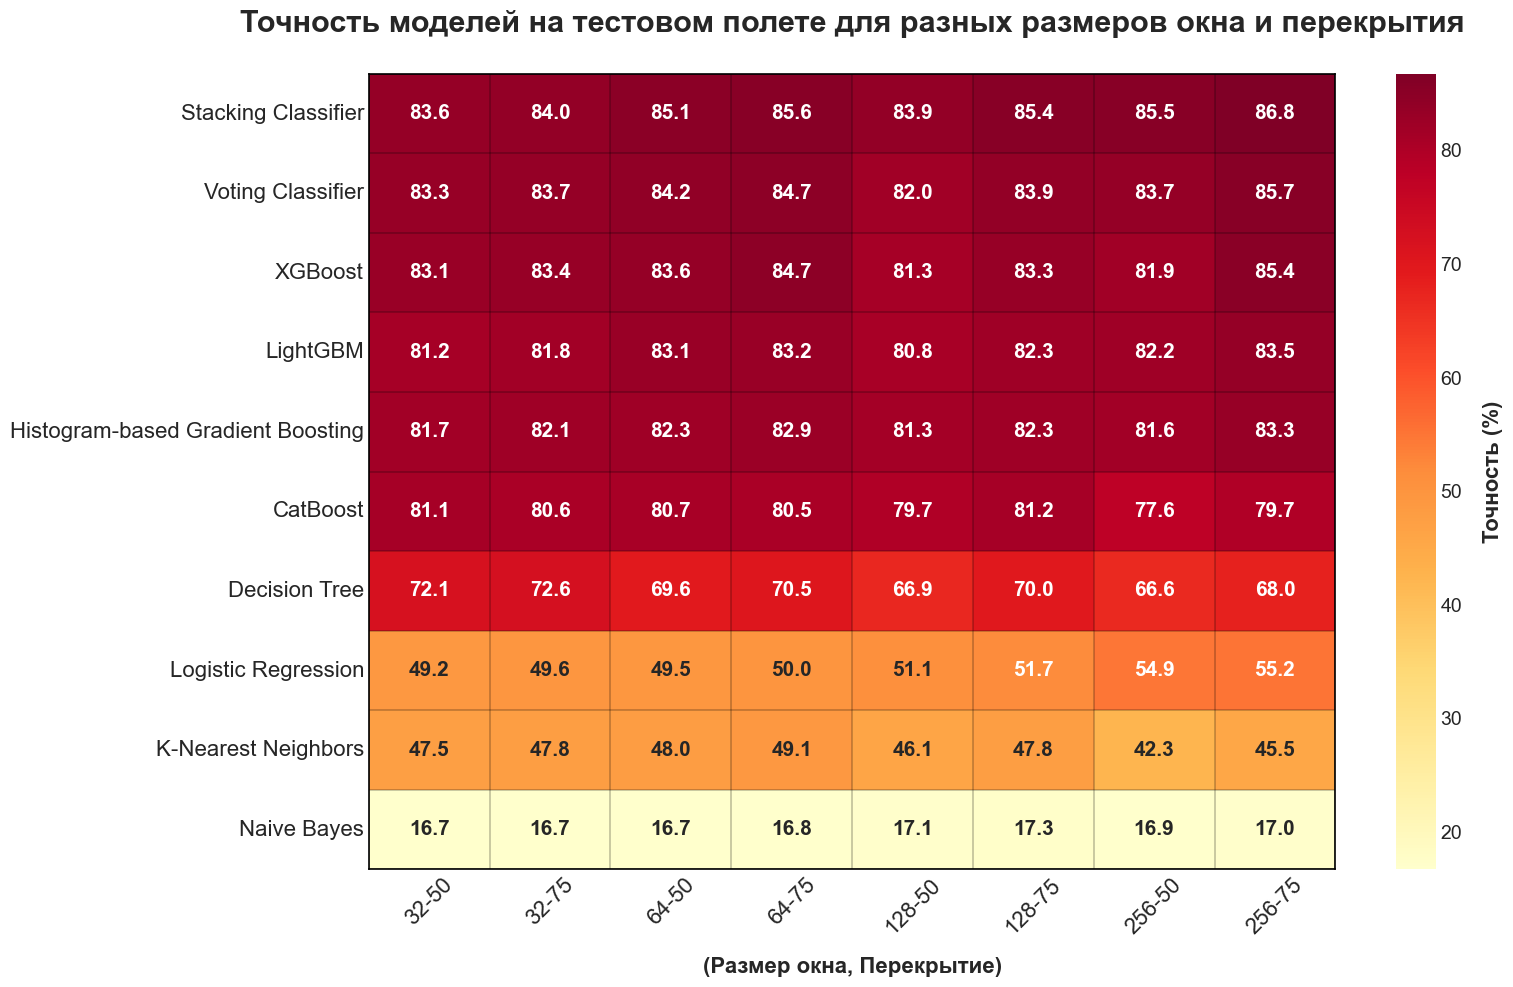

In [12]:
plt.figure(figsize=(16, 10))

# Создание сводной таблицы
pivot_accuracy = df_results.pivot_table(
    values='Accuracy_Sep', 
    index='Model', 
    columns=['Window Size', 'Overlap']
)

# Сортировка моделей по средней точности
model_order = df_results.groupby('Model')['Accuracy_Sep'].mean().sort_values(ascending=False).index
pivot_accuracy = pivot_accuracy.reindex(model_order)

# Создание тепловой карты
ax = sns.heatmap(pivot_accuracy, 
                 annot=True, 
                 fmt='.1f', 
                 cmap='YlOrRd', 
                 linecolor='black',
                 linewidths=0, 
                 cbar=True,
                 annot_kws={'size': 15, 'weight': 'bold'})

# Рисуем линии вручную
for i in range(pivot_accuracy.shape[0] + 1):
    ax.axhline(i, color='black', linewidth=0.3)
for i in range(pivot_accuracy.shape[1] + 1):
    ax.axvline(i, color='black', linewidth=0.3)
    
# Чёрная рамка вокруг графика
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

# Настройка цветовой шкалы
cbar = ax.collections[0].colorbar
cbar.set_label('Точность (%)', fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=14)
cbar.ax.yaxis.labelpad = 15

# Настройка параметров графика
plt.title('Точность моделей на тестовом полете для разных размеров окна и перекрытия', fontsize=22, fontweight='bold', pad=30)
plt.xlabel('(Размер окна, Перекрытие)', fontsize=16, fontweight='bold', labelpad=14)
plt.ylabel('')
plt.xticks(rotation=45, fontsize=16, fontweight='medium')
plt.yticks(rotation=0, fontsize=16, fontweight='medium')
plt.tight_layout()
plt.grid(False)
plt.savefig('APPLICATIONS/accuracy_sep__heatmap.png', dpi=400, bbox_inches='tight')
plt.show()


## График 2: Сравнение точности моделей для каждого размера окна (по overlap 50% и 75%)

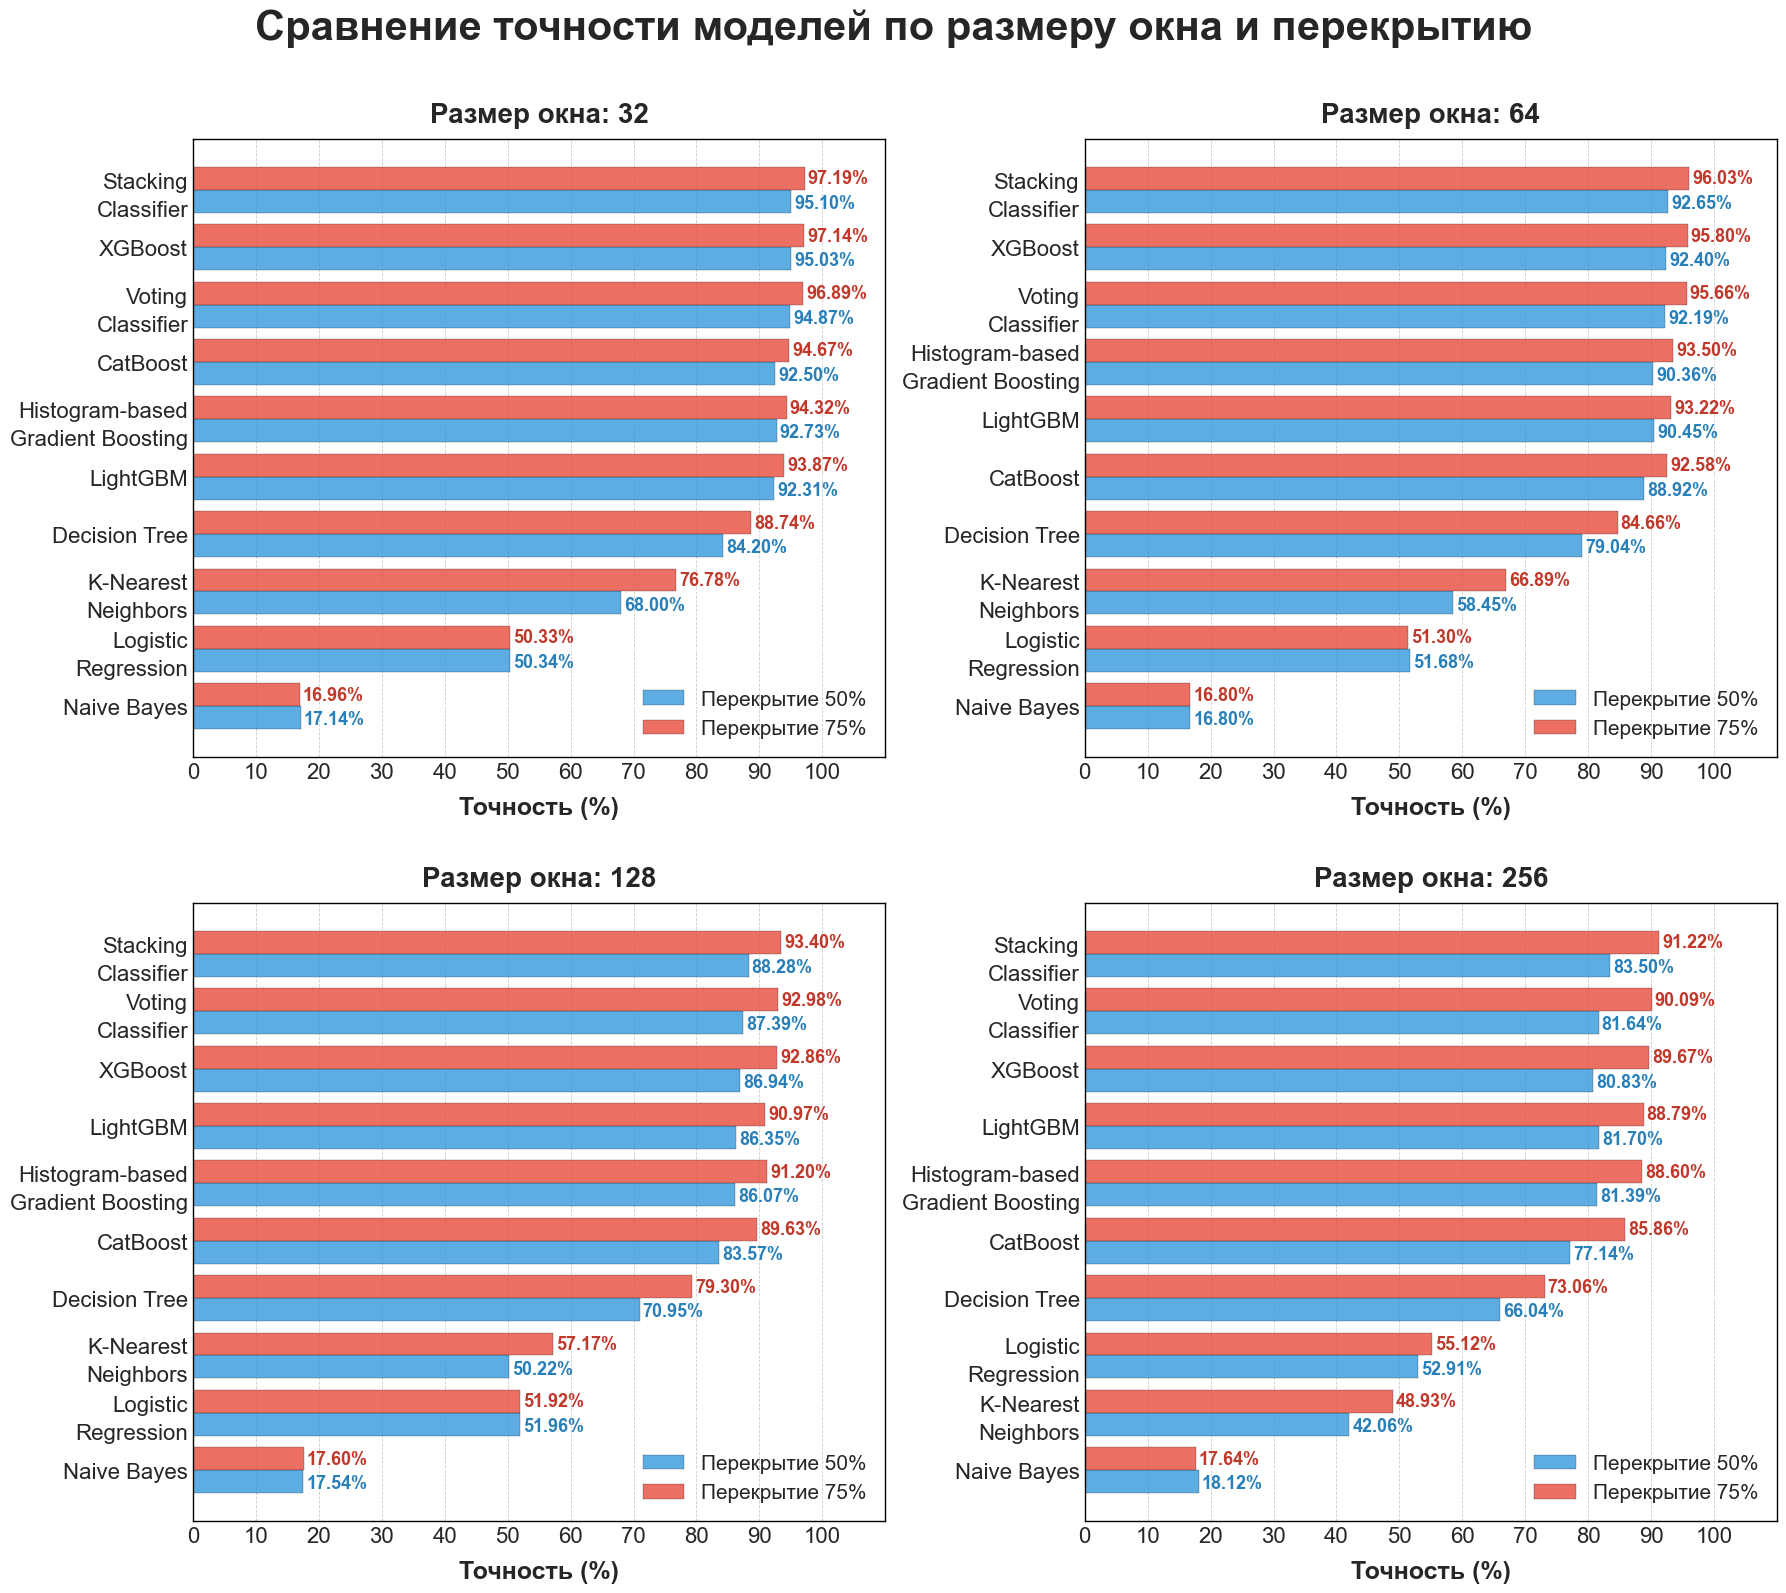

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

window_sizes = sorted(df_results['Window Size'].unique())

for i, ws in enumerate(window_sizes):
    ax = axes[i]
    
    # Добавление черной рамки вокруг каждого графика
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)
    
    # Закрашивание фона
    ax.set_facecolor('white')
    
    # Получение данных для текущего размера окна
    df_ws = df_results[df_results['Window Size'] == ws]
    
    # Получение списка моделей, отсортированного по средней точности
    model_order = df_ws.groupby('Model')['Accuracy'].mean().sort_values(ascending=True).index
    
    # Создние многострочных названий моделей
    model_labels = []
    for model in model_order:
        if ' ' in model:
            words = model.split()
            if len(words) >= 2 and sum(map(len, words)) > 15:
                model_labels.append(f'{words[0]}\n{" ".join(words[1:])}')
            else:
                model_labels.append(model)
        else:
            model_labels.append(model)
    
    # Позиции для моделей на оси y
    y_pos = np.arange(len(model_order))
    height = 0.4
    
    # Данные для overlap 50% и 75%
    acc_50 = [df_ws[(df_ws['Model'] == model) & (df_ws['Overlap'] == 50)]['Accuracy'].values[0] 
              if len(df_ws[(df_ws['Model'] == model) & (df_ws['Overlap'] == 50)]) > 0 else 0 
              for model in model_order]
    
    acc_75 = [df_ws[(df_ws['Model'] == model) & (df_ws['Overlap'] == 75)]['Accuracy'].values[0] 
              if len(df_ws[(df_ws['Model'] == model) & (df_ws['Overlap'] == 75)]) > 0 else 0 
              for model in model_order]
    
    # Отрисовка полосок для overlap 50%
    bars50 = ax.barh(y_pos - height/2, acc_50, height, label='Перекрытие 50%', 
                     color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.2)
    
    # Отрисовка полосок для overlap 75%
    bars75 = ax.barh(y_pos + height/2, acc_75, height, label='Перекрытие 75%', 
                     color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.2)
    
    # Добавление значений на полоски
    for bar in bars50:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2-0.03, f'{width:.2f}%', 
                ha='left', va='center', fontsize=13, color='#2980b9', fontweight='bold')
    
    for bar in bars75:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', 
                ha='left', va='center', fontsize=13, color='#c0392b', fontweight='bold')
    
    # Настройка осей
    ax.tick_params(axis='x', labelsize=16)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_labels, fontsize=16, linespacing=1.5)
    ax.set_xlim(0, 110)
    ax.set_xticks(np.arange(0, 108, 10))
    ax.set_xlabel('Точность (%)', fontsize=18, fontweight='bold', labelpad=10)
    ax.set_title(f'Размер окна: {ws}', fontsize=20, fontweight='bold', pad=12)
    ax.grid(axis='x', linestyle='--', alpha=0.4, linewidth=0.6, color='gray')
    ax.legend(loc='lower right', fontsize=15)
    
plt.subplots_adjust(hspace=150, wspace=0)  # Увеличение отступа между subplots
plt.suptitle('Сравнение точности моделей по размеру окна и перекрытию', fontsize=30, fontweight='bold', y=0.994)
plt.tight_layout()
plt.savefig('APPLICATIONS/accuracy_by_window_size_split.png', dpi=600, bbox_inches='tight')
plt.show()


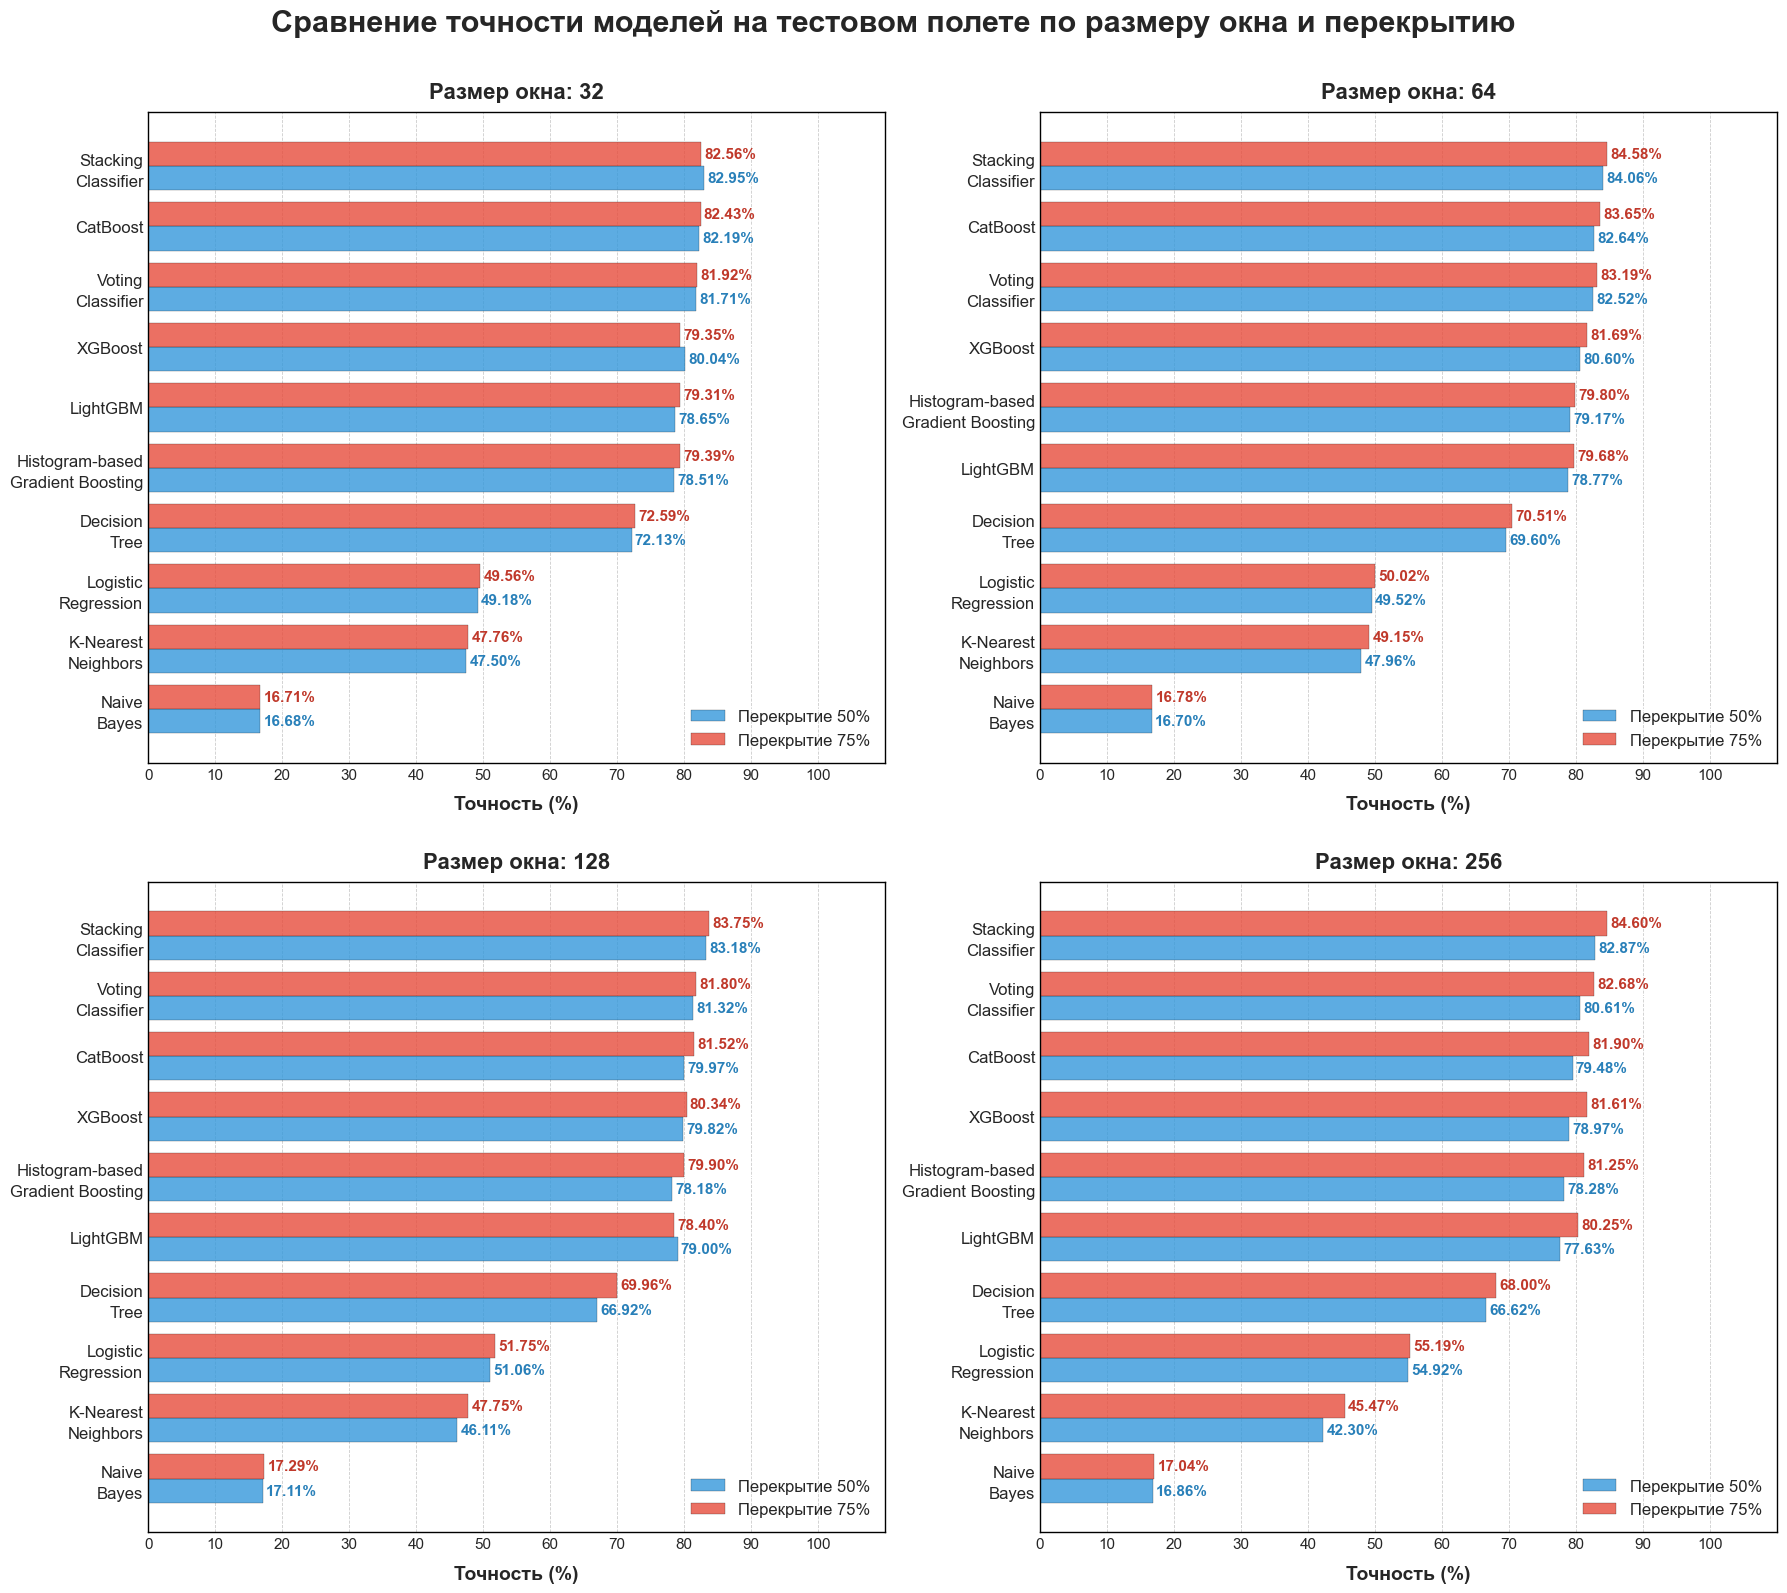

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

window_sizes = sorted(df_results['Window Size'].unique())

for i, ws in enumerate(window_sizes):
    ax = axes[i]
    
    # Добавление черной рамки вокруг каждого графика
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)
    
    # Закрашивание фона
    ax.set_facecolor('white')
    
    # Получение данных для текущего размера окна
    df_ws = df_results[df_results['Window Size'] == ws]
    
    # Получение списка моделей, отсортированного по средней точности
    model_order = df_ws.groupby('Model')['Accuracy_Sep'].mean().sort_values(ascending=True).index
    
    # Создние многострочных названий моделей
    model_labels = []
    for model in model_order:
        if ' ' in model:
            words = model.split()
            if len(words) >= 2:
                model_labels.append(f'{words[0]}\n{" ".join(words[1:])}')
            else:
                model_labels.append(model)
        else:
            model_labels.append(model)
    
    # Позиции для моделей на оси y
    y_pos = np.arange(len(model_order))
    height = 0.4
    
    # Данные для overlap 50% и 75%
    acc_50 = [df_ws[(df_ws['Model'] == model) & (df_ws['Overlap'] == 50)]['Accuracy_Sep'].values[0] 
              if len(df_ws[(df_ws['Model'] == model) & (df_ws['Overlap'] == 50)]) > 0 else 0 
              for model in model_order]
    
    acc_75 = [df_ws[(df_ws['Model'] == model) & (df_ws['Overlap'] == 75)]['Accuracy_Sep'].values[0] 
              if len(df_ws[(df_ws['Model'] == model) & (df_ws['Overlap'] == 75)]) > 0 else 0 
              for model in model_order]
    
    # Отрисовка полосок для overlap 50%
    bars50 = ax.barh(y_pos - height/2, acc_50, height, label='Перекрытие 50%', 
                     color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.2)
    
    # Отрисовка полосок для overlap 75%
    bars75 = ax.barh(y_pos + height/2, acc_75, height, label='Перекрытие 75%', 
                     color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.2)
    
    # Добавление значений на полоски
    for bar in bars50:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', 
                ha='left', va='center', fontsize=11, color='#2980b9', fontweight='bold')
    
    for bar in bars75:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', 
                ha='left', va='center', fontsize=11, color='#c0392b', fontweight='bold')
    
    # Настройка осей
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_labels, fontsize=12, linespacing=1.5)
    ax.set_xlim(0, 110)
    ax.set_xticks(np.arange(0, 108, 10))
    ax.set_xlabel('Точность (%)', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_title(f'Размер окна: {ws}', fontsize=16, fontweight='bold', pad=10)
    ax.grid(axis='x', linestyle='--', alpha=0.4, linewidth=0.6, color='gray')
    ax.legend(loc='lower right', fontsize=12)

plt.subplots_adjust(hspace=150, wspace=0)  # Увеличение отступа между subplots
plt.suptitle('Сравнение точности моделей на тестовом полете по размеру окна и перекрытию', fontsize=22, fontweight='bold', y=0.994)
plt.tight_layout()
plt.savefig('APPLICATIONS/accuracy_sep_by_window_size_split.png', dpi=400, bbox_inches='tight')
plt.show()


## График 3: Сравнение времени обучения и инференса по размерам окон

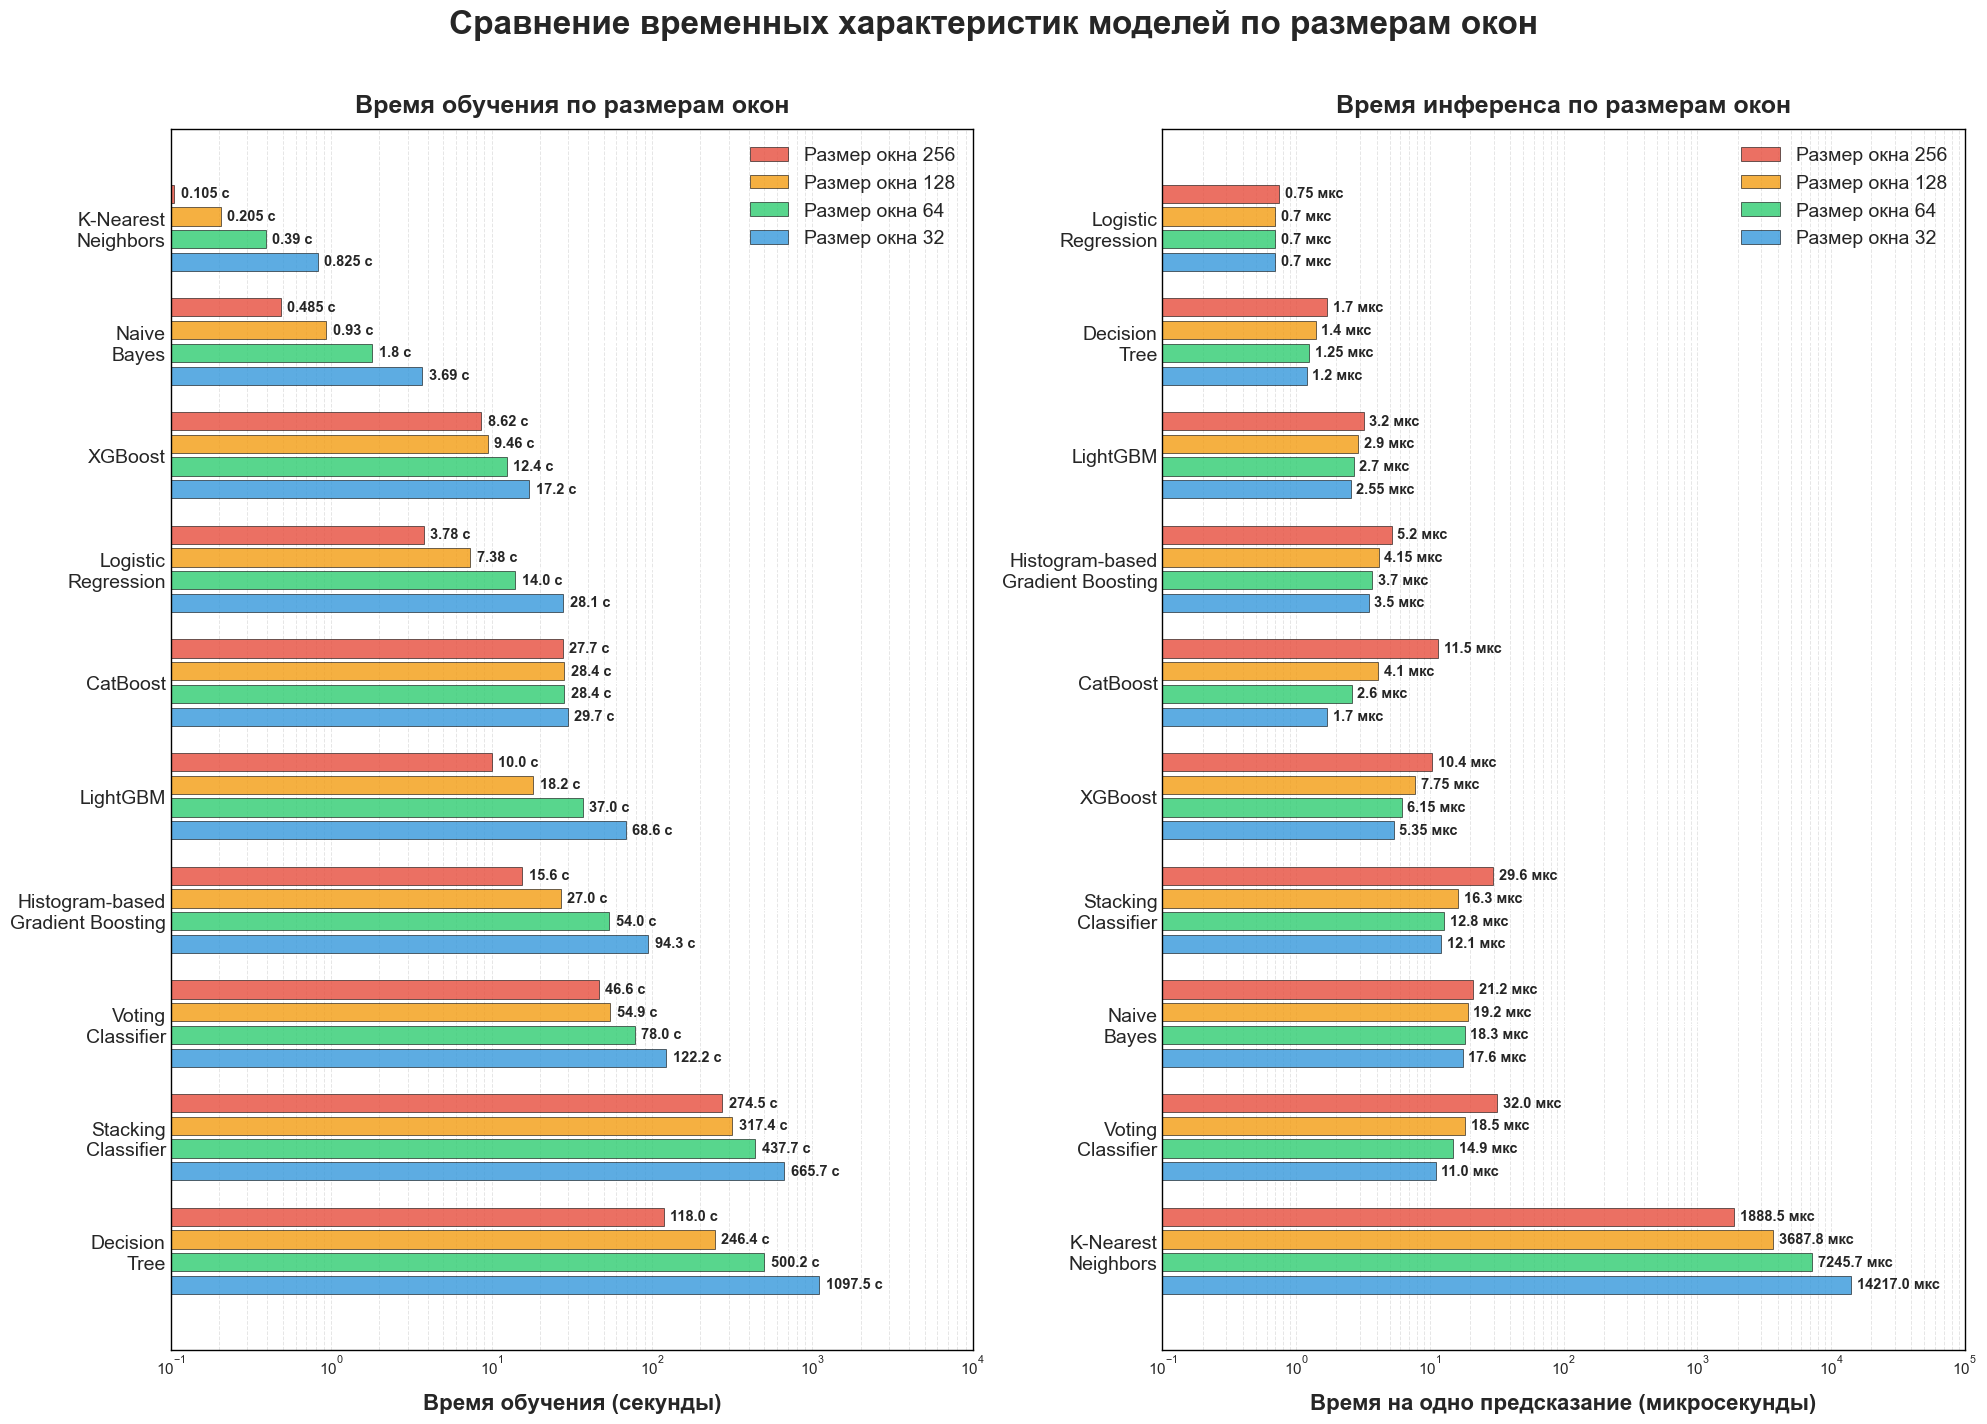

In [65]:
log_base = 10
training_limits = (0.1, 10000)
inference_limits = (0.1, 100000)

window_sizes = [32, 64, 128, 256]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

def fmt(v, unit):
    if v >= 10: return f'{round(v,1)} {unit}'
    if v >= 1:  return f'{round(v,2)} {unit}'
    if v >= 0.1:return f'{round(v,3)} {unit}'
    return f'{round(v,4)} {unit}'

def split_name(n):
    w = n.split()
    return f'{w[0]}\n{" ".join(w[1:])}' if len(w) > 1 else n

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

for ax, metric, limits, xlabel, title, mul, unit in [
    (axes[0], 'Training_Time', training_limits,
     'Время обучения (секунды)',
     'Время обучения по размерам окон', 1, 'c'),
    (axes[1], 'Time_per_pred_ms', inference_limits,
     'Время на одно предсказание (микросекунды)',
     'Время инференса по размерам окон', 1000, 'мкс')
]:
    ax.set_facecolor('white')
    
    order = (df_results.groupby('Model')[metric]
             .mean().sort_values(ascending=False).index)

    for i, model in enumerate(order):
        df_m = df_results[df_results['Model'] == model]
        y = i * 5
        values = [df_m[df_m['Window Size']==ws][metric].mean()*mul
                  for ws in window_sizes]

        for j, (ws, val, c) in enumerate(zip(window_sizes, values, colors)):
            ax.barh(y+j, val, 0.8, color=c, alpha=0.8,
                    edgecolor='black', linewidth=0.5,
                    label=f'Размер окна {ws}' if i==0 else "")
            ax.text(val*1.1, y+j, fmt(val, unit),
                    ha='left', va='center',
                    fontsize=10.5, fontweight='bold')

    ax.set_xscale('log', base=log_base)
    ax.set_xlim(*limits)
    ax.set_yticks([i*5+1.5 for i in range(len(order))])
    ax.set_yticklabels([split_name(m) for m in order], fontsize=14)
    ax.set_xlabel(xlabel, fontsize=16, fontweight='bold', labelpad=12)
    ax.set_title(title, fontsize=18, fontweight='bold', pad=12)
    ax.grid(axis='x', linestyle='--', alpha=0.2,
            which='both', linewidth=0.7, color='gray')
    ax.set_axisbelow(True)

    h,l = ax.get_legend_handles_labels()
    ax.legend(h[::-1], l[::-1], loc='upper right',
              fontsize=14, framealpha=1, edgecolor='black')

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

plt.suptitle('Сравнение временных характеристик моделей по размерам окон',
             fontsize=24, fontweight='bold', y=1.015)

plt.tight_layout()
plt.savefig('APPLICATIONS/time_comparison_by_window.png',
            dpi=400, bbox_inches='tight')
plt.show()

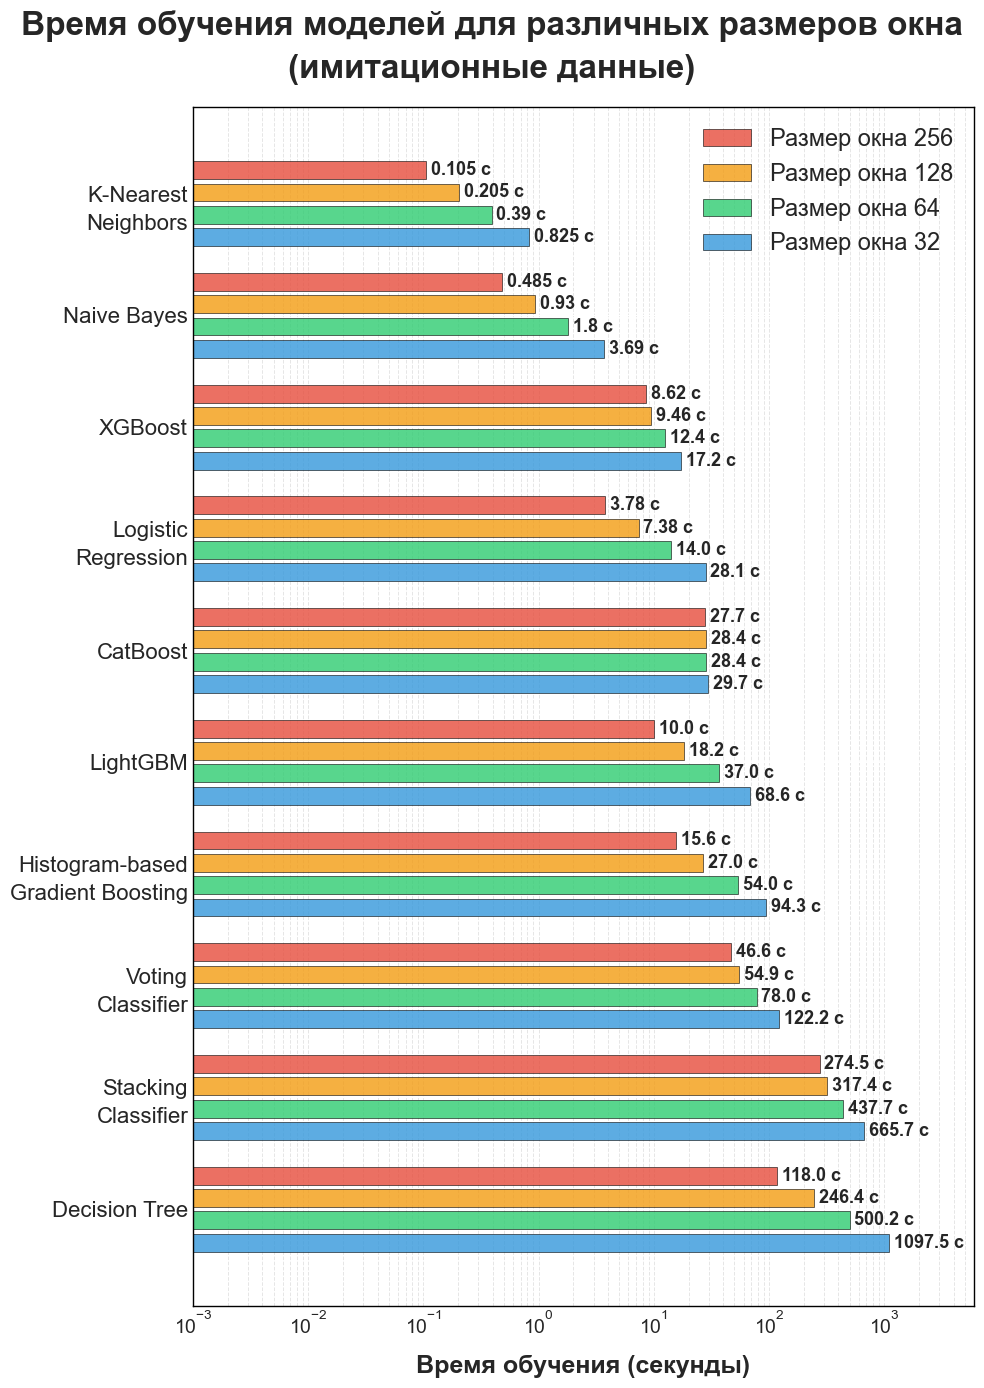

In [57]:
import matplotlib.pyplot as plt
import numpy as np

log_base = 10
training_limits = (0.001, 6000)

window_sizes = [32, 64, 128, 256]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

def fmt(v, unit):
    if v >= 10: return f'{round(v,1)} {unit}'
    if v >= 1:  return f'{round(v,2)} {unit}'
    if v >= 0.1:return f'{round(v,3)} {unit}'
    return f'{round(v,4)} {unit}'

def split_name(n):
    words = n.split()
    if len(words) >= 2 and sum(map(len, words)) > 15:
        return f'{words[0]}\n{" ".join(words[1:])}'
    else:
        return n

# Создание фигуры и оси
fig = plt.figure(figsize=(10, 14))
ax = fig.add_subplot(111)  # Создаем ось явно

ax.set_facecolor('white')

metric = 'Training_Time'
mul = 1
unit = 'c'

# Сортировка моделей по времени обучения
order = (df_results.groupby('Model')[metric]
         .mean().sort_values(ascending=False).index)

for i, model in enumerate(order):
    df_m = df_results[df_results['Model'] == model]
    y = i * 5
    values = [df_m[df_m['Window Size']==ws][metric].mean()*mul
              for ws in window_sizes]
    
    for j, (ws, val, c) in enumerate(zip(window_sizes, values, colors)):
        ax.barh(y+j, val, 0.8, color=c, alpha=0.8,
                edgecolor='black', linewidth=0.5,
                label=f'Размер окна {ws}' if i==0 else "")
        ax.text(val*1.1, y+j, fmt(val, unit),
                ha='left', va='center',
                fontsize=13, fontweight='bold')
        
ax.tick_params(axis='x', labelsize=14)
ax.set_xscale('log', base=log_base)
ax.set_xlim(*training_limits)
ax.set_yticks([i*5+1.5 for i in range(len(order))])
ax.set_yticklabels([split_name(m) for m in order], fontsize=16, linespacing=1.5)
ax.set_xlabel('Время обучения (секунды)', fontsize=18, fontweight='bold', labelpad=12)

# ЗАМЕНА: используем fig.suptitle вместо ax.set_title
fig.suptitle('Время обучения моделей для различных размеров окна\n(имитационные данные)',
             fontsize=24, fontweight='bold', y=0.99, linespacing=1.5)

ax.grid(axis='x', linestyle='--', alpha=0.2,
        which='both', linewidth=0.7, color='gray')
ax.set_axisbelow(True)

# Легенда
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], loc='upper right',
          fontsize=17, framealpha=1, edgecolor='black')

# Рамка
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# Настройка отступов для suptitle
plt.subplots_adjust(top=0.93)  # Освобождаем место для suptitle
plt.tight_layout()
plt.savefig('APPLICATIONS/training_time_by_window.png',
            dpi=600, bbox_inches='tight')
plt.show()

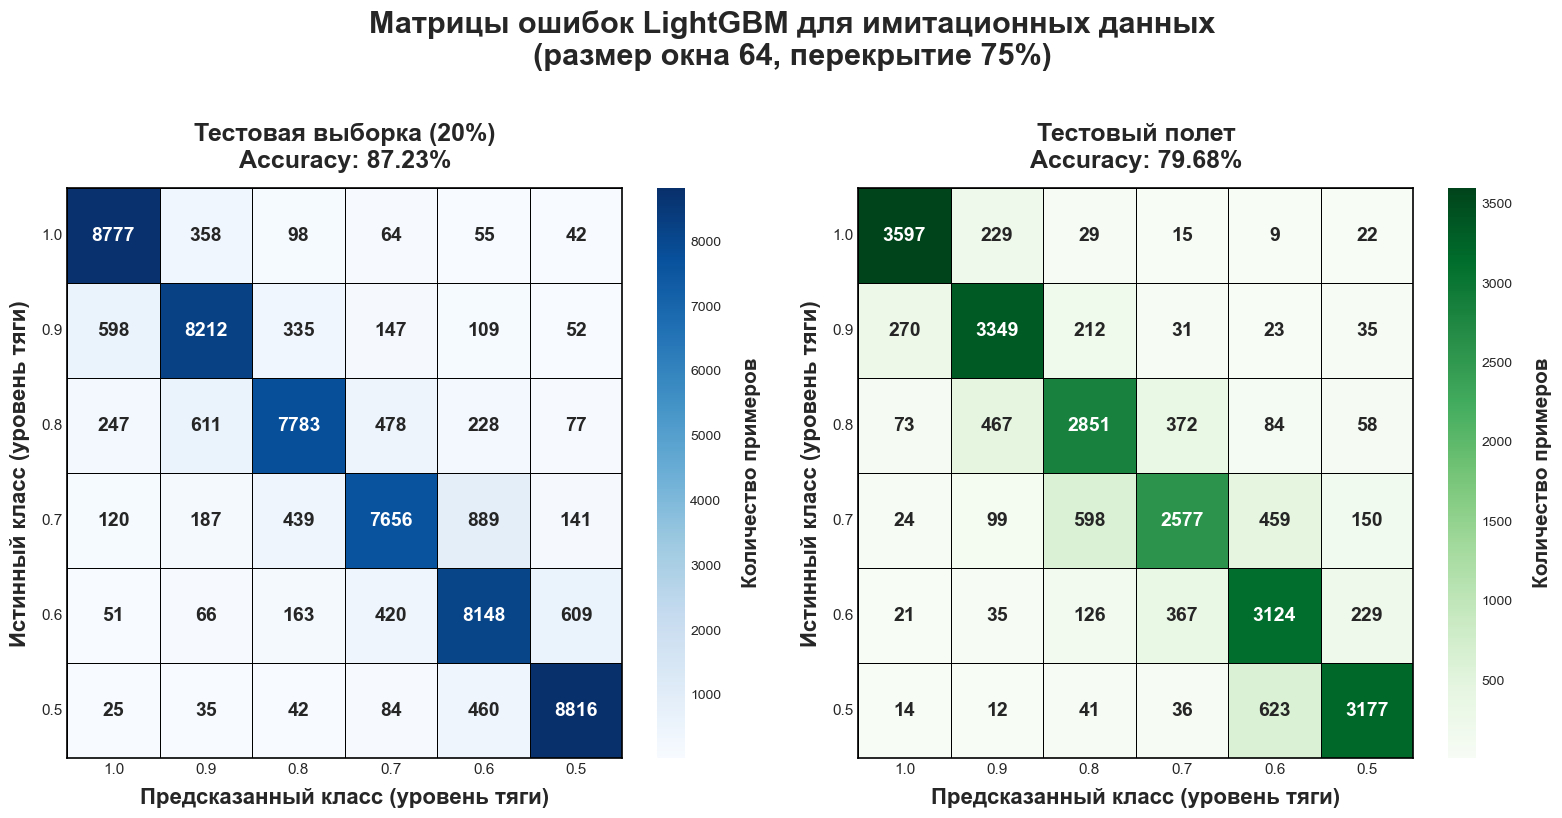

Точность на стандартном тестовом наборе: 87.23%
Точность на независимом тестовом полете: 79.68%


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

# Загрузка сохраненных результатов
with open('DATA/related_info/models_training_results.json', 'r', encoding='utf-8') as f:
    all_results = json.load(f)

# Поиск файла с имитационными данными (окно 64, перекрытие 75%)
target_file = None
for file_name in all_results.keys():
    if 'MATLAB_features' in file_name and 'ws64' in file_name and 'overlap75' in file_name:
        target_file = file_name
        break

if target_file is None:
    raise ValueError("Файл с имитационными данными (ws64, overlap75) не найден")

# Извлечение матриц ошибок для LightGBM
cm_test = np.array(all_results[target_file]['LightGBM']['Confusion_Matrix'])
cm_separate = np.array(all_results[target_file]['LightGBM']['Confusion_Matrix_Sep'])

# Получение значений точности
acc_test = all_results[target_file]['LightGBM']['Accuracy']
acc_separate = all_results[target_file]['LightGBM']['Accuracy_Sep']

# Подписи классов для имитационных данных (уровни тяги)
class_labels_display = ['1.0', '0.9', '0.8', '0.7', '0.6', '0.5']

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (18, 8)
plt.rcParams['font.size'] = 12

# Создание фигуры с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Первая матрица: стандартный тестовый набор (20%) ---
ax1 = axes[0]
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels_display, yticklabels=class_labels_display,
            linewidths=0.5, linecolor='black', ax=ax1,
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Количество примеров'})

# Настройка цветовой шкалы для первого графика
cbar1 = ax1.collections[0].colorbar
cbar1.set_label('Количество примеров', fontsize=15, fontweight='bold')
cbar1.ax.tick_params(labelsize=10)
cbar1.ax.yaxis.labelpad = 15

# Настройка осей и заголовка для первого графика
ax1.set_title(f'Тестовая выборка (20%)\nAccuracy: {acc_test:.2f}%', 
              fontsize=18, fontweight='bold', pad=15)
ax1.set_xlabel('Предсказанный класс (уровень тяги)', fontsize=16, fontweight='bold', labelpad=8)
ax1.set_ylabel('Истинный класс (уровень тяги)', fontsize=16, fontweight='bold', labelpad=8)

# --- Вторая матрица: независимый тестовый полет ---
ax2 = axes[1]
sns.heatmap(cm_separate, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_labels_display, yticklabels=class_labels_display,
            linewidths=0.5, linecolor='black', ax=ax2,
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Количество примеров'})

# Настройка цветовой шкалы для второго графика
cbar2 = ax2.collections[0].colorbar
cbar2.set_label('Количество примеров', fontsize=15, fontweight='bold')
cbar2.ax.tick_params(labelsize=10)
cbar2.ax.yaxis.labelpad = 15

# Настройка осей и заголовка для второго графика
ax2.set_title(f'Тестовый полет\nAccuracy: {acc_separate:.2f}%', 
              fontsize=18, fontweight='bold', pad=15)
ax2.set_xlabel('Предсказанный класс (уровень тяги)', fontsize=16, fontweight='bold', labelpad=8)
ax2.set_ylabel('Истинный класс (уровень тяги)', fontsize=16, fontweight='bold', labelpad=8)

# Добавление черной рамки вокруг каждого графика
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.2)

# Настройка подписей осей
for ax in axes:
    ax.set_xticklabels(class_labels_display, rotation=0, fontsize=11)
    ax.set_yticklabels(class_labels_display, rotation=0, fontsize=11)

# Общий заголовок
plt.suptitle('Матрицы ошибок LightGBM для имитационных данных\n(размер окна 64, перекрытие 75%)', 
             fontsize=22, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('APPLICATIONS/confusion_matrix_lightgbm_simulated.png', dpi=400, bbox_inches='tight')
plt.show()

print(f"Точность на стандартном тестовом наборе: {acc_test:.2f}%")
print(f"Точность на независимом тестовом полете: {acc_separate:.2f}%")

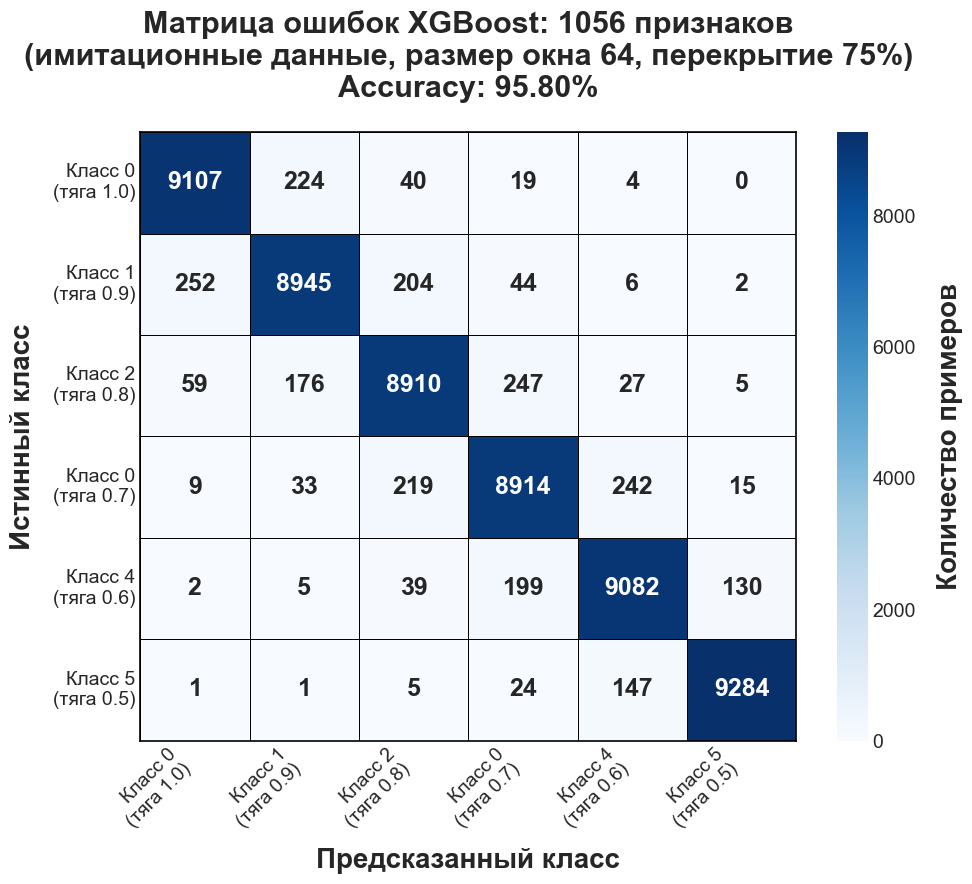

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

# Загрузка сохраненных результатов
with open('DATA/related_info/models_training_results_GB.json', 'r', encoding='utf-8') as f:
    all_results = json.load(f)

# Поиск файла с имитационными данными (окно 64, перекрытие 75%)
target_file = None
for file_name in all_results.keys():
    if 'MATLAB_features' in file_name and 'ws64' in file_name and 'overlap75' in file_name:
        target_file = file_name
        break

if target_file is None:
    raise ValueError("Файл с реальными данными (ws32, overlap75) не найден")

# Извлечение матрицы ошибок для LightGBM
cm_array = np.array(all_results[target_file]['XGBoost']['Confusion_Matrix'])
acc_test = all_results[target_file]['XGBoost']['Accuracy']

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

# Создание фигуры
fig, ax = plt.subplots(1, 1, figsize=(10, 9))

# Подписи классов для имитационных данных (уровни тяги)
class_labels = ['Класс 0\n(тяга 1.0)', 'Класс 1\n(тяга 0.9)', 'Класс 2\n(тяга 0.8)', 
                'Класс 0\n(тяга 0.7)', 'Класс 4\n(тяга 0.6)', 'Класс 5\n(тяга 0.5)']

# Построение тепловой карты
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='black', 
            annot_kws={'size': 18, 'weight': 'bold'},
            cbar_kws={'label': 'Количество примеров'})

# Настройка цветовой шкалы
cbar = ax.collections[0].colorbar
cbar.set_label('Количество примеров', fontsize=20, fontweight='bold')
cbar.ax.tick_params(labelsize=14)
cbar.ax.yaxis.labelpad = 15

# Настройка осей и заголовка
plt.title(f'Матрица ошибок XGBoost: 1056 признаков\n(имитационные данные, размер окна 64, перекрытие 75%)\nAccuracy: {acc_test:.2f}%', 
          fontsize=22, fontweight='bold', pad=25)
plt.xlabel('Предсказанный класс', fontsize=20, fontweight='bold', labelpad=12)
plt.ylabel('Истинный класс', fontsize=20, fontweight='bold', labelpad=12)

# Добавление черной рамки вокруг графика
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.savefig('APPLICATIONS/confusion_matrix_xgboost_real.png', dpi=600, bbox_inches='tight')
plt.show()

In [18]:
NUM_OF_FEATURES = 200
random_state = 42
file_name = "MATLAB_features_ws64_overlap75.csv"

features_df = pd.read_csv(f'DATA/features/{file_name}')

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    selected_features = json.load(f)["optimal_features"][:NUM_OF_FEATURES]

features_df = features_df[selected_features + ["Класс"]]

# Разбиение данных на признаки и целевую переменную
X = features_df.drop(columns=["Класс"])
y = features_df["Класс"].values

# Преобразование y: (1.0 -> 0, 0.9 -> 1, 0.8 -> 2, 0.7 -> 3, 0.6 -> 4, 0.5 -> 5)
class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))}
y = np.array([class_mapping[val] for val in y])

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)

models = {
    "CatBoost": CatBoostClassifier(
        random_state=random_state, 
        task_type="GPU", 
        devices="0:1:2:3", 
        silent=True, 
        allow_writing_files=False, 
        save_snapshot=False,
        iterations=300,
        depth=10,
    ),
    "Histogram-based Gradient Boosting": HistGradientBoostingClassifier(
        random_state=random_state,
        max_iter=300,
        max_depth=10,
    ),
    "XGBoost": XGBClassifier(
        random_state=random_state, 
        device="cuda", 
        tree_method="hist", 
        n_jobs=-1,
        n_estimators=300,
        max_depth=10,
        learning_rate=0.25,
        colsample_bytree=1,
        subsample=1,
        gamma=0,
        min_child_weight=1
    ),
    "LightGBM": LGBMClassifier(
        random_state=random_state,
        verbose=-1,
        n_estimators=300,
        max_depth=10,
    )
}

results_key = f"{file_name}"
all_results[results_key] = {}

for model_name, model in models.items():

    print("-" * 53)
    print(f"\n{model_name}")
    
    # Обучение
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    training_time = time.perf_counter() - start_train

    # Инференс
    start_predict = time.perf_counter()
    y_pred = model.predict(X_test).flatten()
    predict_time = time.perf_counter() - start_predict

    # Расчет метрик качества
    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred, average="weighted") * 100
    recall = recall_score(y_test, y_pred, average="weighted") * 100
    f1 = f1_score(y_test, y_pred, average="weighted") * 100

    # Время на одно предсказание (в миллисекундах)
    time_per_pred = predict_time / len(y_test) * 1000

    # Сохранение результатов
    all_results[results_key][model_name] = {
        "Accuracy": round(accuracy, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1_Score": round(f1, 3),
        "Training_Time": round(training_time, 2),
        "Inference_Time": round(predict_time, 4),
        "Time_per_pred_ms": round(time_per_pred, 4)
    }

    all_results[results_key][model_name]["Confusion_Matrix"] = confusion_matrix(y_test, y_pred).tolist()
    
    # Вывод результатов
    print(f"Время обучения: {training_time:.3f} с")
    print(f"Время инференса: {predict_time:.3f} с, {time_per_pred:.4f} мс на 1 предсказание\n")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy:\t{accuracy:.2f} %")


-----------------------------------------------------

CatBoost
Время обучения: 18.965 с
Время инференса: 0.035 с, 0.0006 мс на 1 предсказание

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      9394
           1       0.91      0.90      0.90      9453
           2       0.89      0.89      0.89      9424
           3       0.90      0.90      0.90      9432
           4       0.91      0.92      0.91      9457
           5       0.96      0.96      0.96      9462

    accuracy                           0.92     56622
   macro avg       0.92      0.92      0.92     56622
weighted avg       0.92      0.92      0.92     56622

Accuracy:	91.72 %
-----------------------------------------------------

Histogram-based Gradient Boosting
Время обучения: 50.812 с
Время инференса: 0.772 с, 0.0136 мс на 1 предсказание

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      9394
           1     

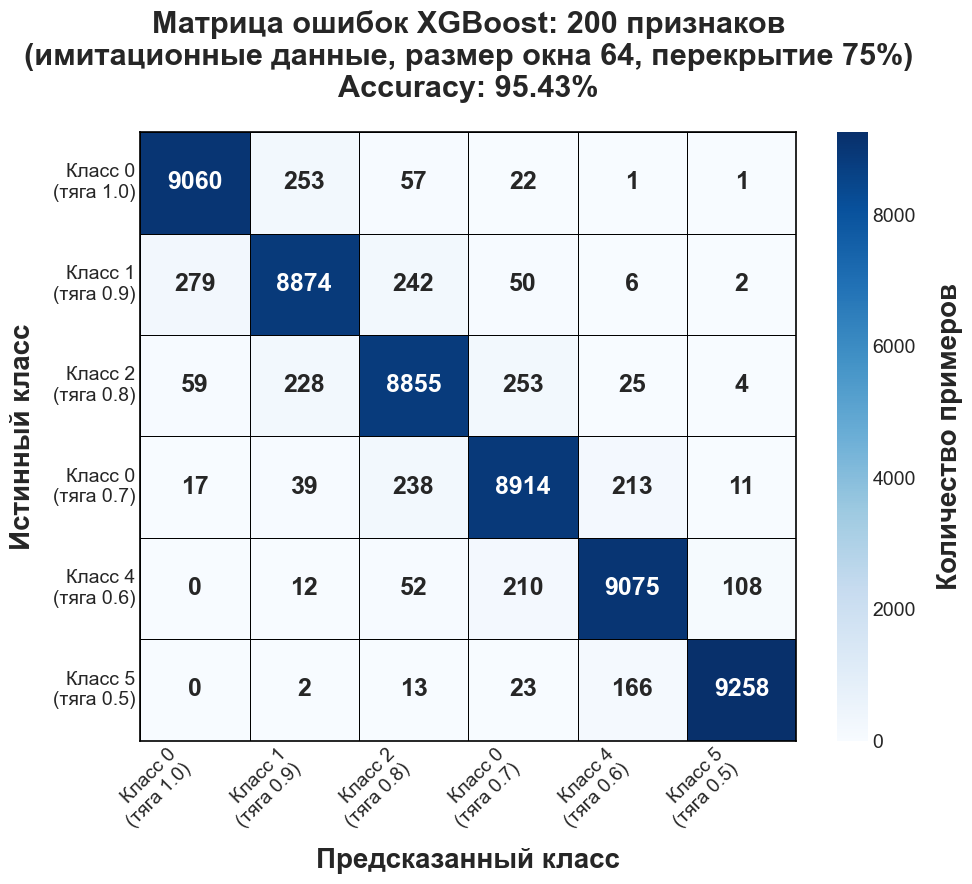

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

# Поиск файла с имитационными данными (окно 64, перекрытие 75%)
target_file = None
for file_name in all_results.keys():
    if 'MATLAB_features' in file_name and 'ws64' in file_name and 'overlap75' in file_name:
        target_file = file_name
        break

if target_file is None:
    raise ValueError("Файл с реальными данными (ws32, overlap75) не найден")

# Извлечение матрицы ошибок для LightGBM
cm_array = np.array(all_results[target_file]['XGBoost']['Confusion_Matrix'])
acc_test = all_results[target_file]['XGBoost']['Accuracy']

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

# Создание фигуры
fig, ax = plt.subplots(1, 1, figsize=(10, 9))

# Подписи классов для имитационных данных (уровни тяги)
class_labels = ['Класс 0\n(тяга 1.0)', 'Класс 1\n(тяга 0.9)', 'Класс 2\n(тяга 0.8)', 
                'Класс 0\n(тяга 0.7)', 'Класс 4\n(тяга 0.6)', 'Класс 5\n(тяга 0.5)']

# Построение тепловой карты
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='black', 
            annot_kws={'size': 18, 'weight': 'bold'},
            cbar_kws={'label': 'Количество примеров'})

# Настройка цветовой шкалы
cbar = ax.collections[0].colorbar
cbar.set_label('Количество примеров', fontsize=20, fontweight='bold')
cbar.ax.tick_params(labelsize=14)
cbar.ax.yaxis.labelpad = 15

# Настройка осей и заголовка
plt.title(f'Матрица ошибок XGBoost: 200 признаков\n(имитационные данные, размер окна 64, перекрытие 75%)\nAccuracy: {acc_test:.2f}%', 
          fontsize=22, fontweight='bold', pad=25)
plt.xlabel('Предсказанный класс', fontsize=20, fontweight='bold', labelpad=12)
plt.ylabel('Истинный класс', fontsize=20, fontweight='bold', labelpad=12)

# Добавление черной рамки вокруг графика
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.savefig('APPLICATIONS/confusion_matrix_xgboost_real_200.png', dpi=600, bbox_inches='tight')
plt.show()